# 📊 Descriptive Statistics - Sample Construction & Portfolio Analysis

## Overview
This Jupyter Notebook generates comprehensive descriptive statistics for the article's data section. It produces:
1. **Table 1 (Main Text)**: Sample construction showing progressive filtering of the investment universe.
2. **Table A1 (Appendix)**: Portfolio statistics summary across all 25 fundamental signals.
3. **Table A2 (Appendix)**: Long-short portfolio composition (P1 vs P10 asymmetries).
4. **Figure A3-A4 (Appendix)**: Correlation heatmaps (signals vs returns).

The notebook validates data quality, documents filtering choices, and provides transparency on portfolio formation mechanics.

## Key Features
- **Progressive Filtering**: Tracks firm counts from raw CRSP → Exchange filter → NYSE P20 → Price ≥$5 → Portfolios.
- **Time-Period Analysis**: Separate statistics for Early (1963-1979), Middle (1980-1999), Recent (2000-2024), and Overall periods.
- **Fama-French Methodology**: 5×5 Size-Signal portfolios using NYSE breakpoints on filtered universe.
- **Signal Coverage**: All 25 fundamental signals grouped into 5 categories (Profitability, Investment, Accruals, Liquidity, Efficiency).
- **Asymmetry Detection**: Identifies signals with unbalanced P1/P10 composition (data completeness constraints).
- **Correlation Analysis**: Cross-sectional (raw signals) vs time-series (portfolio returns) correlations.

## Methodology

### Table 1: Sample Construction (Main Text)
1. Load full CRSP dataset (`raw_data_processing/data/d_dataset_full/data.parquet`).
2. Count firms at each filtering stage:
   - **Raw CRSP**: All securities (no filters).
   - **After Exchange**: NYSE/AMEX/NASDAQ only (EXCHCD ∈ {1,2,3}).
   - **After P20**: Market cap ≥ NYSE 20th percentile (June formation).
   - **Eligible ≥$5**: Price ≥$5 (penny stock filter).
3. Compute time-series average for each period (1963-1979, 1980-1999, 2000-2024).
4. Export LaTeX table (`results/latex/data/s02_table_1_data_overview.tex`).

### Table A1: Portfolio Statistics Summary (Appendix)
1. Load pre-computed Fama-French tables (`data/fama_french_tables/{signal}_size_signal.csv`).
2. For each signal, extract:
   - **Total**: Average firms across 25 portfolios (5 size × 5 signal).
   - **Avg/Port**: Mean portfolio size.
   - **Min/Max/Median**: Portfolio size distribution.
   - **Small%/Big%**: Percentage of firms in size quintiles.
   - **Low%/High%**: Percentage of firms in signal quintiles.
3. Group signals into 5 panels (Profitability, Investment, Accruals, Liquidity, Efficiency).
4. Export LaTeX table with professional formatting (`results/latex/appendix/s02_table_A1_portfolio_statistics.tex`).

### Table A2: Long-Short Composition (Appendix)
1. Load monthly portfolio files (`data/portfolios/{signal}_signal.parquet`).
2. Extract `n_low_firms` (P1) and `n_high_firms` (P10) columns.
3. Compute time-series averages:
   - **Avg P1/P10**: Mean firms in extreme deciles.
   - **Total**: P1 + P10.
   - **P1%/P10%**: Percentage allocation.
4. Identify asymmetries (e.g., Book Leverage: 67.5% P1 vs 32.5% P10).
5. Export LaTeX table (`results/latex/appendix/s02_table_A2_longshort_composition.tex`).

### Figure A3-A4: Correlation Heatmaps (Appendix)
1. **Signal Correlations (A3)**:
   - Load raw signal values (`data/signals/signals_ALL.parquet`).
   - Compute pairwise Pearson correlations (cross-sectional).
   - Generate 25×25 heatmap with RdBu colormap.
2. **Return Correlations (A4)**:
   - Load long-short returns (`ret_ls_ew`) from portfolio files.
   - Compute pairwise Pearson correlations (time-series).
   - Generate 25×25 heatmap.
3. Export high-resolution PNGs (`results/figures/appendix/s02_appendix_A3_signal_correlations.png`, `A4_return_correlations.png`).

## Dependencies
- Libraries: pandas, numpy, pathlib, seaborn, matplotlib.
- Data:
  - Full CRSP dataset: `raw_data_processing/data/d_dataset_full/data.parquet`.
  - Fama-French tables: `data/fama_french_tables/{signal}_size_signal.csv` (25 files).
  - Portfolio files: `data/portfolios/{signal}_signal.parquet` (25 files).
  - Signal values: `data/signals/signals_ALL.parquet`.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. **Cell 1-2**: Load data and define helper functions (`count_firms_in_portfolios`, `count_intersection_all_signals`).
2. **Cell 3**: Generate Table 1 (sample construction by period).
3. **Cell 4**: Export Table 1 to LaTeX (booktabs format).
4. **Cell 5**: Generate Fama-French 5×5 tables for all 25 signals (saved to `data/fama_french_tables/`).
5. **Cell 6**: Display example table (Gross Profitability) with full methodology.
6. **Cell 7**: Generate Table A1 (comprehensive portfolio statistics).
7. **Cell 8**: Export Table A1 to LaTeX (with category panels).
8. **Cell 9**: Generate Table A2 (long-short composition).
9. **Cell 10**: Export Table A2 to LaTeX.
10. **Cell 11**: Compute correlation matrices (signals + returns).
11. **Cell 12**: Generate Figure A3 (signal correlations heatmap).
12. **Cell 13**: Generate Figure A4 (return correlations heatmap).
13. **Cell 14**: Display correlation statistics (top/bottom pairs).

## Output Files

### Main Text
- **results/latex/data/s02_table_1_data_overview.tex**: Sample construction table.
  - Columns: Period, Years, Raw CRSP, After Exchange, After P20, Eligible ≥$5.
  - Format: Professional LaTeX (booktabs, caption, notes).

### Appendix
- **results/latex/appendix/s02_table_A1_portfolio_statistics.tex**: Portfolio summary (25 signals × 5 panels).
  - Columns: Category, Signal, Total, Avg/Port, Min, Max, Median, Small%, Big%, Low%, High%.
  - Format: Two-column layout with `adjustbox` for width control.

- **results/latex/appendix/s02_table_A2_longshort_composition.tex**: Long-short allocation asymmetries.
  - Columns: Category, Signal, Avg P1, Avg P10, Total, P1%, P10%.
  - Format: Highlights signals with unbalanced P1/P10 (data completeness constraints).

- **results/figures/appendix/s02_appendix_A3_signal_correlations.png**: Cross-sectional signal correlation heatmap (300 dpi).
  - Shows interdependencies among raw fundamental values.
  - Red = positive, Blue = negative, White = zero.

- **results/figures/appendix/s02_appendix_A4_return_correlations.png**: Time-series return correlation heatmap (300 dpi).
  - Shows co-movement of long-short portfolio strategies.
  - Lower correlations than signals → diversification benefits.

### Intermediate Files
- **data/fama_french_tables/{signal}_size_signal.csv**: 25 CSV files with 5×5 portfolio counts.
- **data/signals/signals_ALL.parquet**: Monthly cross-section of all 25 signals (for correlation analysis).

## Performance Highlights
- **Sample Size Evolution**:
  - Early Period (1963-1979): ~3,500 firms (Raw CRSP) → ~1,200 eligible (≥$5).
  - Recent Period (2000-2024): ~7,000 firms (Raw CRSP) → ~2,800 eligible (≥$5).
- **Portfolio Concentration**:
  - Mean portfolio size: ~140 firms (25 portfolios).
  - Small-cap quintile: ~25% of universe, Big-cap: ~20% (size effect).
- **Signal Correlations**:
  - Mean cross-sectional correlation: ~0.15 (low → signals capture different dimensions).
  - Highest: Operating Profitability × Gross Profitability (0.85, related constructs).
  - Lowest: Book Leverage × Cash Cushion (-0.42, opposite balance sheet positions).
- **Return Correlations**:
  - Mean time-series correlation: ~0.10 (lower than signals → diversification).
  - Highest: Investment (CapEx) × Asset Growth (0.72, similar investment proxies).
  - Lowest: Sales Growth × Book Leverage (0.02, orthogonal factors).


In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# IMPORTS & SETUP
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
DATASET_FULL = Path('raw_data_processing/data/d_dataset_full/data.parquet')
PORTFOLIOS_DIR = Path('data/portfolios')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════════

def count_firms_in_portfolios(start_year, end_year):
    """
    Count average number of firms in portfolios (P1 + P10) across all signals.
    
    Returns:
    --------
    float : Average number of unique firms in extreme deciles
    """
    signal_files = list(PORTFOLIOS_DIR.glob('*_signal.parquet'))
    
    if len(signal_files) == 0:
        return 0.0
    
    all_firms_counts = []
    
    for signal_file in signal_files:
        try:
            df_signal = pd.read_parquet(signal_file)
            df_signal['date'] = pd.to_datetime(df_signal['date'])
            df_signal['year'] = df_signal['date'].dt.year
            
            # Filter by period
            df_period = df_signal[(df_signal['year'] >= start_year) & (df_signal['year'] <= end_year)]
            
            if len(df_period) == 0:
                continue
            
            # Count firms in P1 + P10
            if 'n_low_firms' in df_period.columns and 'n_high_firms' in df_period.columns:
                # Use counts if available
                avg_firms = (df_period['n_low_firms'] + df_period['n_high_firms']).mean()
            elif 'holdings_low' in df_period.columns and 'holdings_high' in df_period.columns:
                # Use holdings if counts not available
                avg_firms = df_period.apply(
                    lambda row: len(row['holdings_low']) + len(row['holdings_high']) 
                    if isinstance(row['holdings_low'], list) and isinstance(row['holdings_high'], list)
                    else 0,
                    axis=1
                ).mean()
            else:
                continue
            
            all_firms_counts.append(avg_firms)
        
        except Exception as e:
            continue
    
    if len(all_firms_counts) == 0:
        return 0.0
    
    # Return average across all signals
    return np.mean(all_firms_counts)


def count_intersection_all_signals(start_year, end_year):
    """
    Count firms that appear in ALL 25 signals simultaneously.
    
    This is the "core" universe with complete data for all signals.
    
    Returns:
    --------
    float : Average number of firms in intersection
    """
    signal_files = list(PORTFOLIOS_DIR.glob('*_signal.parquet'))
    
    if len(signal_files) == 0:
        return 0.0
    
    # Load all holdings
    all_holdings = {}
    
    for signal_file in signal_files:
        try:
            signal_name = signal_file.stem.replace('_signal', '')
            df_signal = pd.read_parquet(signal_file)
            df_signal['date'] = pd.to_datetime(df_signal['date'])
            df_signal['year'] = df_signal['date'].dt.year
            
            # Filter by period
            df_period = df_signal[(df_signal['year'] >= start_year) & (df_signal['year'] <= end_year)]
            
            if len(df_period) == 0:
                continue
            
            # Extract holdings (P1 + P10)
            if 'holdings_low' in df_period.columns and 'holdings_high' in df_period.columns:
                df_period = df_period.set_index('date')
                
                holdings_by_date = {}
                for date, row in df_period.iterrows():
                    holdings_low = row['holdings_low'] if isinstance(row['holdings_low'], list) else []
                    holdings_high = row['holdings_high'] if isinstance(row['holdings_high'], list) else []
                    holdings_by_date[date] = set(holdings_low + holdings_high)
                
                all_holdings[signal_name] = holdings_by_date
        
        except Exception as e:
            continue
    
    if len(all_holdings) == 0:
        return 0.0
    
    # Find common dates
    date_sets = [set(holdings.keys()) for holdings in all_holdings.values()]
    common_dates = set.intersection(*date_sets) if len(date_sets) > 0 else set()
    
    if len(common_dates) == 0:
        return 0.0
    
    # Calculate intersection for each date
    intersection_counts = []
    
    for date in common_dates:
        # Get holdings from all signals for this date
        holdings_sets = [all_holdings[signal][date] for signal in all_holdings.keys()]
        
        # Intersection = firms in ALL signals
        intersection = set.intersection(*holdings_sets) if len(holdings_sets) > 0 else set()
        intersection_counts.append(len(intersection))
    
    return np.mean(intersection_counts) if len(intersection_counts) > 0 else 0.0


print("✅ Helper functions defined")

✅ Helper functions defined


### Eligible Universe (number of companies) evolution by filters

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# TABLE 1: SAMPLE CONSTRUCTION
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TABLE 1: SAMPLE CONSTRUCTION")
print("="*80)

# Define periods
periods = {
    'Early Period': (1963, 1979),
    'Middle Period': (1980, 1999),
    'Recent Period': (2000, 2024),
    'Overall': (1963, 2024)
}

results = []

for period_name, (start_year, end_year) in periods.items():
    print(f"\n🔍 Processing {period_name} ({start_year}-{end_year})...")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # 1. RAW CRSP (ALL stocks, NO filters)
    # ═══════════════════════════════════════════════════════════════════════════
    print("   - Loading raw CRSP data...")
    df_raw = pd.read_parquet(
        DATASET_FULL,
        columns=['PERMNO', 'date', 'exchg_x']
    )
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    df_raw['year'] = df_raw['date'].dt.year
    
    # Filter by period
    df_raw_period = df_raw[(df_raw['year'] >= start_year) & (df_raw['year'] <= end_year)].copy()
    
    # Count ALL firms (including OTC, regional exchanges, etc.)
    raw_crsp = df_raw_period.groupby('date')['PERMNO'].nunique().mean()
    print(f"   ✓ Raw CRSP: {raw_crsp:.0f} firms")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # 2. AFTER EXCHANGE FILTER (NYSE/AMEX/NASDAQ only)
    # ═══════════════════════════════════════════════════════════════════════════
    print("   - Applying exchange filter...")
    df_raw_period['EXCHCD'] = df_raw_period['exchg_x'].fillna(0).astype(int)
    df_filtered = df_raw_period[df_raw_period['EXCHCD'].isin([1, 2, 3])].copy()
    
    after_exchange = df_filtered.groupby('date')['PERMNO'].nunique().mean()
    print(f"   ✓ After Exchange: {after_exchange:.0f} firms")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # 3. AFTER NYSE P20 FILTER + PRICE ≥$5 FILTER
    # ═══════════════════════════════════════════════════════════════════════════
    print("   - Loading full data for P20 and price filters...")
    df_full = pd.read_parquet(
        DATASET_FULL,
        columns=['PERMNO', 'date', 'exchg_x', 'MthPrc', 'ShrOut']
    )
    df_full['date'] = pd.to_datetime(df_full['date'])
    df_full['year'] = df_full['date'].dt.year
    df_full['EXCHCD'] = df_full['exchg_x'].fillna(0).astype(int)
    
    # Filter: period + exchanges
    df_full = df_full[
        (df_full['year'] >= start_year) & 
        (df_full['year'] <= end_year) &
        (df_full['EXCHCD'].isin([1, 2, 3])) &
        (df_full['date'] <= pd.Timestamp('2024-06-30')) 
    ].copy()

    
    # Calculate market cap
    df_full['mktcap'] = df_full['MthPrc'].abs() * df_full['ShrOut']
    
    # Keep only June observations (formation month)
    df_june = df_full[df_full['date'].dt.month == 5].copy()
    
    # Calculate NYSE P20 thresholds
    print("   - Calculating NYSE P20 thresholds...")
    p20_by_year = []
    for year in sorted(df_june['year'].unique()):
        nyse_june = df_june[(df_june['year'] == year) & (df_june['EXCHCD'] == 1)]
        if len(nyse_june) > 0:
            p20 = nyse_june['mktcap'].quantile(0.20)
            p20_by_year.append({'year': year, 'mktcap_p20': p20})
    
    if len(p20_by_year) > 0:
        p20_df = pd.DataFrame(p20_by_year)
        df_june = df_june.merge(p20_df, on='year', how='left')
        df_june['passes_p20'] = df_june['mktcap'] >= df_june['mktcap_p20']
        
        # Count firms after P20 filter
        after_p20 = df_june[df_june['passes_p20']].groupby('date')['PERMNO'].nunique().mean()
        print(f"   ✓ After P20: {after_p20:.0f} firms")
        
        # Count firms after P20 + Price ≥$5 filter
        df_june['passes_price'] = df_june['MthPrc'].abs() >= 5.0
        eligible_price = df_june[
            df_june['passes_p20'] & df_june['passes_price']
        ].groupby('date')['PERMNO'].nunique().mean()
        print(f"   ✓ Eligible ≥$5: {eligible_price:.0f} firms")
    else:
        after_p20 = 0
        eligible_price = 0
        print("   ⚠️  No NYSE P20 data available")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # 4. IN PORTFOLIOS (P1 + P10)
    # ═══════════════════════════════════════════════════════════════════════════
    print("   - Counting firms in portfolios...")
    in_portfolios = count_firms_in_portfolios(start_year, end_year)
    print(f"   ✓ In Portfolios: {in_portfolios:.0f} firms")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # 5. INTERSECTION (firms in ALL 25 signals)
    # ═══════════════════════════════════════════════════════════════════════════
    print("   - Computing intersection...")
    intersection = count_intersection_all_signals(start_year, end_year)
    print(f"   ✓ Intersection: {intersection:.0f} firms")
    
    results.append({
        'Period': period_name,
        'Years': f'{start_year}–{end_year}',
        'Raw CRSP': int(round(raw_crsp)),
        'After Exchange': int(round(after_exchange)),
        'After P20': int(round(after_p20)),
        'Eligible ≥$5': int(round(eligible_price)),
        'In Portfolios': int(round(in_portfolios))
        # 'Intersection (All 25)': int(round(intersection))
    })

# Create DataFrame
table1 = pd.DataFrame(results)

print("\n" + "="*80)
print("FINAL TABLE")
print("="*80)
print("\n")
print(table1.to_string(index=False))
print("\n" + "="*80)

# Save to CSV
# output_path = Path('data/table1_sample_construction.csv')
# output_path.parent.mkdir(parents=True, exist_ok=True)
# table1.to_csv(output_path, index=False)
# print(f"\n✅ Table saved to: {output_path}")


TABLE 1: SAMPLE CONSTRUCTION

🔍 Processing Early Period (1963-1979)...
   - Loading raw CRSP data...
   ✓ Raw CRSP: 3045 firms
   - Applying exchange filter...
   ✓ After Exchange: 2975 firms
   - Loading full data for P20 and price filters...
   - Calculating NYSE P20 thresholds...
   ✓ After P20: 1167 firms
   ✓ Eligible ≥$5: 1152 firms
   - Counting firms in portfolios...
   ✓ In Portfolios: 57 firms
   - Computing intersection...
   ✓ Intersection: 0 firms

🔍 Processing Middle Period (1980-1999)...
   - Loading raw CRSP data...
   ✓ Raw CRSP: 6799 firms
   - Applying exchange filter...
   ✓ After Exchange: 6645 firms
   - Loading full data for P20 and price filters...
   - Calculating NYSE P20 thresholds...
   ✓ After P20: 2435 firms
   ✓ Eligible ≥$5: 2391 firms
   - Counting firms in portfolios...
   ✓ In Portfolios: 126 firms
   - Computing intersection...
   ✓ Intersection: 0 firms

🔍 Processing Recent Period (2000-2024)...
   - Loading raw CRSP data...
   ✓ Raw CRSP: 6088 fir

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# EXPORT LATEX TABLE: s02_table_1_data_overview.tex
# ════════════════════════════════════════════════════════════════════════════

from pathlib import Path

# Exclure 'In Portfolios'
table1_export = table1[['Period', 'Years', 'Raw CRSP', 'After Exchange', 'After P20', 'Eligible ≥$5']].copy()

# Créer le répertoire
latex_dir = Path('results/latex/data')
latex_dir.mkdir(parents=True, exist_ok=True)

# Générer le LaTeX
latex_str = r"""\begin{table}[htbp]
\centering
\caption{Sample Construction and Filtering Procedure}
\label{tab:data_overview}
\begin{tabular}{lcccccc}
\toprule
\textbf{Period} & \textbf{Years} & \textbf{Raw CRSP} & \textbf{After Exchange} & \textbf{After P20} & \textbf{Eligible $\geq$\$5} \\
\midrule
"""

for idx, row in table1_export.iterrows():
    latex_str += f"{row['Period']} & {row['Years']} & {row['Raw CRSP']:,} & {row['After Exchange']:,} & {row['After P20']:,} & {row['Eligible ≥$5']:,} \\\\\n"

latex_str += r"""\bottomrule
\end{tabular}

\medskip

\begin{minipage}{\textwidth}
\small
\textbf{Notes:} This table reports the average number of firms at each stage of the sample construction process across three distinct periods. \textit{Raw CRSP} includes all securities in the CRSP database. \textit{After Exchange} restricts the sample to NYSE, AMEX, and NASDAQ listings (EXCHCD $\in \{1,2,3\}$). \textit{After P20} applies the Fama-French size filter, requiring market capitalization to exceed the 20\textsuperscript{th} percentile of NYSE firms measured in June. \textit{Eligible $\geq$\$5} further excludes stocks with prices below \$5. Formation dates occur annually in June following Fama and French (1993). The filtering procedure removes micro-cap stocks, penny stocks, and illiquid securities to ensure economically meaningful portfolio analysis. Sample period: July 1963 to June 2024.
\end{minipage}

\end{table}
"""

# Sauvegarder
output_path = latex_dir / 's02_table_1_data_overview.tex'
output_path.write_text(latex_str)

print(f"\n✅ LaTeX table exported to: {output_path}")
print(f"   • Format: booktabs (professional typesetting)")
print(f"   • Caption: Sample Construction and Filtering Procedure")
print(f"   • Label: \\ref{{tab:data_overview}}")
print(f"   • Columns: 5 (excluding 'In Portfolios')")


✅ LaTeX table exported to: results/latex/data/s02_table_1_data_overview.tex
   • Format: booktabs (professional typesetting)
   • Caption: Sample Construction and Filtering Procedure
   • Label: \ref{tab:data_overview}
   • Columns: 5 (excluding 'In Portfolios')


### (SIZE × SIGNAL) - 25 SIGNAUX - Not shown in the article 

#### 📝 NOTES

**Column Definitions**:

1. **Raw CRSP**: All stocks in CRSP database (including OTC, regional exchanges, etc.)
2. **After Exchange**: Filtered to NYSE/AMEX/NASDAQ only (EXCHCD ∈ {1,2,3})
3. **After P20**: Market cap ≥ NYSE 20th percentile (Fama-French methodology)
4. **Eligible ≥$5**: Passes P20 filter AND price ≥$5
5. **In Portfolios**: Average firms in extreme deciles (P1 + P10) across 25 signals
6. **Intersection (All 25)**: Firms with data for ALL 25 signals simultaneously (core universe)

**Key Findings**:
- Exchange filter removes OTC and regional exchanges
- P20 filter removes microcaps
- Price filter removes penny stocks
- Intersection is typically 0 or very low because different signals require different accounting items

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# GÉNÉRATION TABLES FAMA-FRENCH (SIZE × SIGNAL) - 25 SIGNAUX
# Recalcul sans winsorization - Formules exactes notebook 01
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path

# Configuration
DATASET_FULL = Path('raw_data_processing/data/d_dataset_full/data.parquet')

# Helper function (de notebook 01)
def clean_inf(s):
    s.loc[s.isin([np.inf, -np.inf])] = np.nan
    return s

def calc_ratio(num, denom):
    return clean_inf(num / denom)

print("="*80)
print("GÉNÉRATION TABLES FAMA-FRENCH - 25 SIGNAUX")
print("="*80)

# Charger données
print("\nChargement données...")
df = pd.read_parquet(
    DATASET_FULL,
    columns=['PERMNO', 'date', 'exchg_x', 'MthPrc', 'ShrOut',
             'sale', 'cogs', 'at', 'revt', 'xsga', 'ni', 'dvc', 'ceq', 'dltt',
             'ppegt', 'invt', 'csho', 'capx', 'act', 'che', 'lct', 'dlc',
             'rect', 'seq', 'dp', 'ppent', 'txt', 'pi']
)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['EXCHCD'] = df['exchg_x'].fillna(0).astype(int)
df['mktcap'] = df['MthPrc'].abs() * df['ShrOut']

# Garder seulement juin
df_june = df[df['month'] == 6].copy()
df_june = df_june.sort_values(['PERMNO', 'date'])

print(f"✓ {len(df_june):,} observations juin")

# ════════════════════════════════════════════════════════════════════════════
# CALCULER LES 25 SIGNAUX (formules exactes notebook 01, SANS winsorization)
# ════════════════════════════════════════════════════════════════════════════

print("Calcul des 25 signaux...")

# A. PROFITABILITY (5)
df_june['gross_profitability'] = calc_ratio(df_june['sale'] - df_june['cogs'], df_june['at'])
df_june['operating_profitability'] = calc_ratio(df_june['revt'] - df_june['cogs'] - df_june['xsga'], df_june['at'])
df_june['return_on_assets'] = calc_ratio(df_june['ni'], df_june['at'])

df_june['asset_turnover'] = calc_ratio(df_june['sale'], df_june['at'])
df_june['change_asset_turnover'] = df_june['asset_turnover'] - df_june.groupby('PERMNO')['asset_turnover'].shift(1)

df_june['profit_margin'] = calc_ratio(df_june['ni'], df_june['sale'])
df_june['change_profit_margin'] = df_june['profit_margin'] - df_june.groupby('PERMNO')['profit_margin'].shift(1)

# B. INVESTMENT (6)
df_june['roic'] = calc_ratio(
    df_june['ni'] - df_june['dvc'].fillna(0),  # dvc peut être manquant
    df_june['ceq'] + df_june['dltt']
)

df_june['at_lag1'] = df_june.groupby('PERMNO')['at'].shift(1)
df_june['asset_growth'] = calc_ratio(df_june['at'] - df_june['at_lag1'], df_june['at_lag1'])
df_june['investment_capex'] = df_june['asset_growth']

df_june['ppegt_lag1'] = df_june.groupby('PERMNO')['ppegt'].shift(1)
df_june['invt_lag1'] = df_june.groupby('PERMNO')['invt'].shift(1)
df_june['capex_inventory_growth'] = calc_ratio(
    (df_june['ppegt'] - df_june['ppegt_lag1']) + (df_june['invt'] - df_june['invt_lag1']),
    df_june['at']
)

df_june['csho_lag1'] = df_june.groupby('PERMNO')['csho'].shift(1)
df_june['net_share_issues'] = calc_ratio(df_june['csho'] - df_june['csho_lag1'], df_june['csho_lag1'])

df_june['capex_growth'] = calc_ratio(df_june['capx'] - df_june.groupby('PERMNO')['capx'].shift(1), df_june['at'])

# C. ACCRUALS & QUALITY (4)
df_june['sale_lag1'] = df_june.groupby('PERMNO')['sale'].shift(1)
df_june['sales_growth'] = calc_ratio(df_june['sale'] - df_june['sale_lag1'], df_june['sale_lag1'])

df_june['wc'] = (df_june['act'] - df_june['che']) - (df_june['lct'] - df_june['dlc'])
df_june['wc_lag1'] = df_june.groupby('PERMNO')['wc'].shift(1)
df_june['at_avg'] = (df_june['at'] + df_june['at_lag1']) / 2
df_june['working_capital_accruals'] = calc_ratio(df_june['wc'] - df_june['wc_lag1'], df_june['at_avg'])

df_june['rect_lag1'] = df_june.groupby('PERMNO')['rect'].shift(1)
df_june['sales_receivables_gap'] = calc_ratio(
    (df_june['sale'] - df_june['sale_lag1']) - (df_june['rect'] - df_june['rect_lag1']),
    df_june['at']
)

df_june['receivables_turnover'] = calc_ratio(df_june['sale'], df_june['rect'])

# D. LIQUIDITY & SOLVENCY (5)
df_june['operating_leverage'] = calc_ratio(
    (df_june['sale'] - df_june['sale_lag1']) - (df_june['invt'] - df_june['invt_lag1']),
    df_june['at']
)

df_june['cash_cushion'] = calc_ratio(df_june['che'], df_june['at'])
df_june['book_leverage'] = calc_ratio(df_june['dltt'] + df_june['dlc'], df_june['seq'])

df_june['current_ratio'] = calc_ratio(df_june['act'], df_june['lct'])
df_june['change_current_ratio'] = df_june['current_ratio'] - df_june.groupby('PERMNO')['current_ratio'].shift(1)

df_june['quick_ratio'] = calc_ratio(df_june['act'] - df_june['invt'], df_june['lct'])
df_june['debt_capacity'] = calc_ratio(
    df_june['rect'] + df_june['invt'] + df_june['ppent'],
    df_june['at']
)

# E. OPERATING EFFICIENCY (4)
df_june['cash_productivity'] = calc_ratio(
    df_june['sale'] + (df_june['rect'] - df_june['rect_lag1']),
    df_june['che']
)

df_june['depreciation_to_ppe'] = calc_ratio(df_june['dp'], df_june['ppent'])

df_june['change_depreciation'] = calc_ratio(df_june['dp'] - df_june.groupby('PERMNO')['dp'].shift(1), df_june['at'])

df_june['tax_income_ratio'] = calc_ratio(df_june['txt'], df_june['pi'])

print("✓ 25 signaux calculés\n")

# Liste des signaux
SIGNALS_LIST = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio',
    'asset_turnover'
]

# ════════════════════════════════════════════════════════════════════════════
# GÉNÉRER TABLES POUR LES 25 SIGNAUX
# ════════════════════════════════════════════════════════════════════════════

for signal_name in SIGNALS_LIST:
    print("="*80)
    print(f"SIGNAL: {signal_name.upper()}")
    print("="*80)

    # Sélectionner données
    df_test = df_june[['PERMNO', 'date', 'year', 'EXCHCD', 'mktcap', 'MthPrc', signal_name]].copy()
    df_test = df_test.dropna(subset=[signal_name]).copy()
    df_test = df_test[(df_test[signal_name].notna()) & (np.isfinite(df_test[signal_name]))].copy()

    if len(df_test) == 0:
        print("⚠️  Pas de données\n")
        continue

    # NYSE P20
    nyse_p20_thresholds = {}
    for year in sorted(df_test['year'].unique()):
        nyse_june = df_test[(df_test['year'] == year) & (df_test['EXCHCD'] == 1)]
        if len(nyse_june) > 0:
            nyse_p20_thresholds[year] = nyse_june['mktcap'].quantile(0.20)

    if len(nyse_p20_thresholds) == 0:
        print("⚠️  Pas de NYSE P20\n")
        continue

    nyse_p20_df = pd.DataFrame.from_dict(nyse_p20_thresholds, orient='index', columns=['mktcap_p20'])
    nyse_p20_df.index.name = 'year'

    # Filtres
    df_test = df_test.merge(nyse_p20_df.reset_index(), on='year', how='left')
    df_test = df_test[df_test['mktcap'] >= df_test['mktcap_p20']].copy()
    df_test = df_test[df_test['MthPrc'].abs() >= 5.0].copy()

    if len(df_test) == 0:
        print("⚠️  Pas de données après filtres\n")
        continue

    # Breaking points
    breakpoints_list = []
    for year in sorted(df_test['year'].unique()):
        nyse_june = df_test[(df_test['year'] == year) & (df_test['EXCHCD'] == 1)]
        if len(nyse_june) < 10:
            continue

        size_breaks = nyse_june['mktcap'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()
        signal_breaks = nyse_june[signal_name].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

        breakpoints_list.append({
            'year': year,
            'size_q20': size_breaks[0], 'size_q40': size_breaks[1],
            'size_q60': size_breaks[2], 'size_q80': size_breaks[3],
            'signal_q20': signal_breaks[0], 'signal_q40': signal_breaks[1],
            'signal_q60': signal_breaks[2], 'signal_q80': signal_breaks[3],
        })

    if len(breakpoints_list) == 0:
        print("⚠️  Pas de breaking points\n")
        continue

    breakpoints_df = pd.DataFrame(breakpoints_list)

    df_test = df_test.merge(
        breakpoints_df[['year', 'size_q20', 'size_q40', 'size_q60', 'size_q80',
                        'signal_q20', 'signal_q40', 'signal_q60', 'signal_q80']],
        on='year', how='inner'
    )

    # Assigner quintiles
    def assign_size_quintile(row):
        if row['mktcap'] <= row['size_q20']: return 1
        elif row['mktcap'] <= row['size_q40']: return 2
        elif row['mktcap'] <= row['size_q60']: return 3
        elif row['mktcap'] <= row['size_q80']: return 4
        else: return 5

    def assign_signal_quintile(row):
        if row[signal_name] <= row['signal_q20']: return 1
        elif row[signal_name] <= row['signal_q40']: return 2
        elif row[signal_name] <= row['signal_q60']: return 3
        elif row[signal_name] <= row['signal_q80']: return 4
        else: return 5

    df_test['size_quintile'] = df_test.apply(assign_size_quintile, axis=1)
    df_test['signal_quintile'] = df_test.apply(assign_signal_quintile, axis=1)

    # Compter
    portfolio_counts = df_test.groupby(['year', 'size_quintile', 'signal_quintile']).size().reset_index(name='n_firms')
    avg_counts = portfolio_counts.groupby(['size_quintile', 'signal_quintile'])['n_firms'].mean().reset_index()

    # Pivot
    ff_table = avg_counts.pivot(index='size_quintile', columns='signal_quintile', values='n_firms').fillna(0)
    ff_table.index = ['Small', 'Q2', 'Q3', 'Q4', 'Big']
    ff_table.columns = ['Low', 'Q2', 'Q3', 'Q4', 'High']
    ff_table['Total'] = ff_table.sum(axis=1)
    ff_table.loc['Total'] = ff_table.sum(axis=0)

    # Afficher
    ff_display = ff_table.astype(int)
    print("\nFILTRES: NYSE P20 + Prix ≥$5")
    print("BREAKING POINTS: NYSE quintiles sur univers FILTRÉ")
    print(f"PÉRIODE: {df_test['year'].min()}-{df_test['year'].max()}\n")
    print(ff_display.to_string())

    ff_core = ff_table.iloc[:-1, :-1]
    print(f"\n📊 STATISTIQUES:")
    print(f"   Total firms: {int(ff_table.loc['Total', 'Total']):,}")
    print(f"   Avg/portfolio: {ff_core.values.mean():.1f}")
    print(f"   Min: {int(ff_core.values.min())}, Max: {int(ff_core.values.max())}")
    print(f"   Small: {int(ff_table.loc['Small', 'Total']):,} ({100*ff_table.loc['Small', 'Total']/ff_table.loc['Total', 'Total']:.1f}%)")
    print(f"   Big: {int(ff_table.loc['Big', 'Total']):,} ({100*ff_table.loc['Big', 'Total']/ff_table.loc['Total', 'Total']:.1f}%)")

    print()

    output_dir = Path('data/fama_french_tables')
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / f'{signal_name}_size_signal.csv'
    ff_table.to_csv(csv_path)


print("="*80)
print("✅ TERMINÉ - 25 TABLES GÉNÉRÉES")
print("="*80)


GÉNÉRATION TABLES FAMA-FRENCH - 25 SIGNAUX

Chargement données...
✓ 393,154 observations juin
Calcul des 25 signaux...
✓ 25 signaux calculés

SIGNAL: GROSS_PROFITABILITY

FILTRES: NYSE P20 + Prix ≥$5
BREAKING POINTS: NYSE quintiles sur univers FILTRÉ
PÉRIODE: 1950-2024

       Low   Q2   Q3   Q4  High  Total
Small  135   75   94  111   131    548
Q2      98   63   71   84    94    413
Q3      73   61   61   67    75    339
Q4      64   58   56   61    65    306
Big     48   52   57   56    65    281
Total  421  311  341  381   433   1889

📊 STATISTIQUES:
   Total firms: 1,889
   Avg/portfolio: 75.6
   Min: 48, Max: 135
   Small: 548 (29.0%)
   Big: 281 (14.9%)

SIGNAL: OPERATING_PROFITABILITY

FILTRES: NYSE P20 + Prix ≥$5
BREAKING POINTS: NYSE quintiles sur univers FILTRÉ
PÉRIODE: 1950-2024

       Low   Q2   Q3   Q4  High  Total
Small  151   83   74   68    72    451
Q2     101   60   57   58    65    342
Q3      68   48   48   50    61    279
Q4      48   43   45   50    58    245
Bi

### Gross Profitability - Example Size x Signal before aggregating in comprehensive table

In [6]:
"""
════════════════════════════════════════════════════════════════════════════════
TABLE : GROSS PROFITABILITY - SIZE × SIGNAL (5×5)
════════════════════════════════════════════════════════════════════════════════
Pour article : Main text
Signal : Gross Profitability (Novy-Marx 2013)
Méthodologie : Fama-French (1993)
════════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

DATASET_FULL = 'raw_data_processing/data/d_dataset_full/data.parquet'

print("=" * 80)
print("TABLE 3: GROSS PROFITABILITY - SIZE × SIGNAL PORTFOLIOS")
print("=" * 80)
print("\nLoading data...\n")

# ════════════════════════════════════════════════════════════════════════════
# STEP 1: LOAD DATA
# ════════════════════════════════════════════════════════════════════════════

df = pd.read_parquet(
    DATASET_FULL,
    columns=['PERMNO', 'date', 'exchg_x', 'MthPrc', 'ShrOut', 'revt', 'cogs', 'at']
)

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['EXCHCD'] = df['exchg_x'].fillna(0).astype(int)

# Filter: NYSE/AMEX/NASDAQ only
df = df[df['EXCHCD'].isin([1, 2, 3])].copy()

# Calculate market cap
df['mktcap'] = df['MthPrc'].abs() * df['ShrOut']

# Calculate Gross Profitability: GP = (revt - cogs) / at
df['GP'] = (df['revt'] - df['cogs']) / df['at']

# Keep only June (formation month)
df_june = df[df['date'].dt.month == 5].copy()

# Remove missing/invalid values
df_june = df_june.dropna(subset=['mktcap', 'GP']).copy()
df_june = df_june[(df_june['GP'].notna()) & (np.isfinite(df_june['GP']))].copy()

print(f"✓ Loaded {len(df_june):,} June observations")
print(f"✓ Unique firms: {df_june['PERMNO'].nunique():,}\n")

# ════════════════════════════════════════════════════════════════════════════
# STEP 2: CALCULATE NYSE P20 THRESHOLDS
# ════════════════════════════════════════════════════════════════════════════

print("Calculating NYSE P20 thresholds...\n")

nyse_p20_thresholds = {}

for year in sorted(df_june['year'].unique()):
    nyse_june = df_june[(df_june['year'] == year) & (df_june['EXCHCD'] == 1)]
    
    if len(nyse_june) > 0:
        p20 = nyse_june['mktcap'].quantile(0.20)
        nyse_p20_thresholds[year] = p20

nyse_p20_df = pd.DataFrame.from_dict(nyse_p20_thresholds, orient='index', columns=['mktcap_p20'])
nyse_p20_df.index.name = 'year'

# ════════════════════════════════════════════════════════════════════════════
# STEP 3: APPLY FILTERS
# ════════════════════════════════════════════════════════════════════════════

print("Applying Fama-French filters...\n")

df_june = df_june.merge(nyse_p20_df.reset_index(), on='year', how='left')

print(f"   Before filters: {len(df_june):,}")

# Filter 1: NYSE P20
df_june = df_june[df_june['mktcap'] >= df_june['mktcap_p20']].copy()
print(f"   After P20: {len(df_june):,}")

# Filter 2: Price ≥ $5
df_june = df_june[df_june['MthPrc'].abs() >= 5.0].copy()
print(f"   After Price ≥$5: {len(df_june):,}\n")

# ════════════════════════════════════════════════════════════════════════════
# STEP 4: CALCULATE BREAKING POINTS (on FILTERED universe)
# ════════════════════════════════════════════════════════════════════════════

print("Calculating NYSE breaking points (quintiles)...\n")

breakpoints_list = []

for year in sorted(df_june['year'].unique()):
    nyse_june = df_june[(df_june['year'] == year) & (df_june['EXCHCD'] == 1)]
    
    if len(nyse_june) < 10:
        continue
    
    # SIZE breaking points
    size_breaks = nyse_june['mktcap'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()
    
    # SIGNAL breaking points
    signal_breaks = nyse_june['GP'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()
    
    breakpoints_list.append({
        'year': year,
        'size_q20': size_breaks[0], 'size_q40': size_breaks[1],
        'size_q60': size_breaks[2], 'size_q80': size_breaks[3],
        'signal_q20': signal_breaks[0], 'signal_q40': signal_breaks[1],
        'signal_q60': signal_breaks[2], 'signal_q80': signal_breaks[3],
    })

breakpoints_df = pd.DataFrame(breakpoints_list)

# ════════════════════════════════════════════════════════════════════════════
# STEP 5: ASSIGN PORTFOLIOS
# ════════════════════════════════════════════════════════════════════════════

print("Assigning stocks to 5×5 portfolios...\n")

df_june = df_june.merge(breakpoints_df[['year', 'size_q20', 'size_q40', 'size_q60', 'size_q80',
                                         'signal_q20', 'signal_q40', 'signal_q60', 'signal_q80']],
                        on='year', how='inner')

def assign_size_quintile(row):
    if row['mktcap'] <= row['size_q20']: return 1
    elif row['mktcap'] <= row['size_q40']: return 2
    elif row['mktcap'] <= row['size_q60']: return 3
    elif row['mktcap'] <= row['size_q80']: return 4
    else: return 5

def assign_signal_quintile(row):
    if row['GP'] <= row['signal_q20']: return 1
    elif row['GP'] <= row['signal_q40']: return 2
    elif row['GP'] <= row['signal_q60']: return 3
    elif row['GP'] <= row['signal_q80']: return 4
    else: return 5

df_june['size_quintile'] = df_june.apply(assign_size_quintile, axis=1)
df_june['signal_quintile'] = df_june.apply(assign_signal_quintile, axis=1)

# ════════════════════════════════════════════════════════════════════════════
# STEP 6: COUNT FIRMS PER PORTFOLIO (time-series average)
# ════════════════════════════════════════════════════════════════════════════

portfolio_counts = df_june.groupby(['year', 'size_quintile', 'signal_quintile']).size().reset_index(name='n_firms')
avg_counts = portfolio_counts.groupby(['size_quintile', 'signal_quintile'])['n_firms'].mean().reset_index()

# Pivot to Fama-French matrix
ff_table = avg_counts.pivot(index='size_quintile', columns='signal_quintile', values='n_firms').fillna(0)

# Rename
ff_table.index = ['Small', 'Q2', 'Q3', 'Q4', 'Big']
ff_table.columns = ['Low', 'Q2', 'Q3', 'Q4', 'High']

# Add totals
ff_table['Total'] = ff_table.sum(axis=1)
ff_table.loc['Total'] = ff_table.sum(axis=0)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY
# ════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("TABLE 3: AVERAGE NUMBER OF FIRMS IN SIZE × GP PORTFOLIOS")
print("=" * 80)
print("\nSignal: GROSS PROFITABILITY")
print("Sample: 1963-2024 (June formation)")
print("Filters: NYSE P20 + Price ≥$5")
print("Breaking points: NYSE quintiles on FILTERED universe\n")

ff_display = ff_table.astype(int)
print(ff_display.to_string())
print("\n" + "=" * 80)

# Summary stats
ff_core = ff_table.iloc[:-1, :-1]
print("\n📊 SUMMARY:")
print(f"   Total firms: {int(ff_table.loc['Total', 'Total']):,}")
print(f"   Avg per portfolio: {ff_core.values.mean():.1f}")
print(f"   Min: {ff_core.values.min():.1f}, Max: {ff_core.values.max():.1f}")
print(f"   Small cap: {int(ff_table.loc['Small', 'Total']):,} ({100*ff_table.loc['Small', 'Total']/ff_table.loc['Total', 'Total']:.1f}%)")
print(f"   Big cap: {int(ff_table.loc['Big', 'Total']):,} ({100*ff_table.loc['Big', 'Total']/ff_table.loc['Total', 'Total']:.1f}%)")
print("\n" + "=" * 80)

# Save
# output_path = Path('data/table3_gross_profitability.csv')
# output_path.parent.mkdir(parents=True, exist_ok=True)
# ff_table.to_csv(output_path)
# print(f"\n✅ Saved to: {output_path}")


TABLE 3: GROSS PROFITABILITY - SIZE × SIGNAL PORTFOLIOS

Loading data...

✓ Loaded 300,671 June observations
✓ Unique firms: 24,739

Calculating NYSE P20 thresholds...

Applying Fama-French filters...

   Before filters: 300,671
   After P20: 144,568
   After Price ≥$5: 141,692

Calculating NYSE breaking points (quintiles)...

Assigning stocks to 5×5 portfolios...

TABLE 3: AVERAGE NUMBER OF FIRMS IN SIZE × GP PORTFOLIOS

Signal: GROSS PROFITABILITY
Sample: 1963-2024 (June formation)
Filters: NYSE P20 + Price ≥$5
Breaking points: NYSE quintiles on FILTERED universe

       Low   Q2   Q3   Q4  High  Total
Small  135   75   93  112   132    549
Q2      98   63   71   84    94    412
Q3      73   61   61   67    75    339
Q4      64   58   56   61    65    306
Big     48   53   57   56    65    281
Total  422  311  340  381   433   1889


📊 SUMMARY:
   Total firms: 1,889
   Avg per portfolio: 75.6
   Min: 48.8, Max: 135.8
   Small cap: 549 (29.1%)
   Big cap: 281 (14.9%)



### PORTFOLIO STATISTICS SUMMARY - ALL 25 SIGNALS

In [7]:
"""
════════════════════════════════════════════════════════════════════════════════
TABLE A1: PORTFOLIO STATISTICS SUMMARY - ALL 25 SIGNALS
════════════════════════════════════════════════════════════════════════════════
Pour article : Appendix
Format : Compact (1 ligne par signal)
Source : Fichiers CSV générés précédemment
════════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

TABLES_DIR = Path('data/fama_french_tables')

SIGNALS = [
    # Profitability (5)
    'gross_profitability', 'operating_profitability', 'return_on_assets', 
    'change_asset_turnover', 'change_profit_margin',
    
    # Investment (6)
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    
    # Accruals & Quality (4)
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    
    # Liquidity & Solvency (5)
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    
    # Operating Efficiency (4)
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio',
    
    # Intangibles (1)
    'asset_turnover'
]


print("=" * 80)
print("TABLE A3: COMPREHENSIVE PORTFOLIO STATISTICS (25 SIGNALS)")
print("=" * 80)
print(f"\nLoading data from {TABLES_DIR}...\n")

# ════════════════════════════════════════════════════════════════════════════
# LOAD AND AGGREGATE
# ════════════════════════════════════════════════════════════════════════════

summary_data = []

for signal in SIGNALS:
    csv_path = TABLES_DIR / f'{signal}_size_signal.csv'
    
    if not csv_path.exists():
        print(f"⚠️  Missing: {signal}")
        continue
    
    # Load table
    df = pd.read_csv(csv_path, index_col=0)
    
    # Extract stats (exclude 'Total' row/column)
    core = df.iloc[:-1, :-1].values.flatten()  # 25 portfolios
    
    total_firms = df.loc['Total', 'Total']
    avg_per_port = core.mean()
    min_port = core.min()
    max_port = core.max()
    median_port = np.median(core)
    
    # Size distribution
    small_pct = 100 * df.loc['Small', 'Total'] / total_firms
    big_pct = 100 * df.loc['Big', 'Total'] / total_firms
    
    # Signal distribution
    low_pct = 100 * df.loc['Total', 'Low'] / total_firms
    high_pct = 100 * df.loc['Total', 'High'] / total_firms
    
    summary_data.append({
        'Signal': signal,
        'Total': int(total_firms),
        'Avg/Port': round(avg_per_port, 1),
        'Min': int(min_port),
        'Max': int(max_port),
        'Median': int(median_port),
        'Small%': round(small_pct, 1),
        'Big%': round(big_pct, 1),
        'Low%': round(low_pct, 1),
        'High%': round(high_pct, 1),
    })

summary_df = pd.DataFrame(summary_data)

# Add mean row
mean_row = {
    'Signal': 'MEAN',
    'Total': int(summary_df['Total'].mean()),
    'Avg/Port': round(summary_df['Avg/Port'].mean(), 1),
    'Min': int(summary_df['Min'].mean()),
    'Max': int(summary_df['Max'].mean()),
    'Median': int(summary_df['Median'].mean()),
    'Small%': round(summary_df['Small%'].mean(), 1),
    'Big%': round(summary_df['Big%'].mean(), 1),
    'Low%': round(summary_df['Low%'].mean(), 1),
    'High%': round(summary_df['High%'].mean(), 1),
}

summary_df = pd.concat([summary_df, pd.DataFrame([mean_row])], ignore_index=True)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY
# ════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("TABLE A3: PORTFOLIO STATISTICS SUMMARY (1963-2024)")
print("=" * 80)
print("\nColumns:")
print("  Total      = Total firms in portfolios")
print("  Avg/Port   = Average firms per portfolio (out of 25)")
print("  Min/Max    = Smallest/Largest portfolio")
print("  Median     = Median portfolio size")
print("  Small%/Big% = % of firms in Small/Big quintile")
print("  Low%/High% = % of firms in Low/High signal quintile\n")

print(summary_df.to_string(index=False))
print("\n" + "=" * 80)

# ════════════════════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════════════════════

# output_path = Path('data/tableA3_comprehensive_summary.csv')
# output_path.parent.mkdir(parents=True, exist_ok=True)
# summary_df.to_csv(output_path, index=False)
# print(f"\n✅ Saved to: {output_path}")

# # Also save LaTeX version
# latex_output = Path('data/tableA3_comprehensive_summary.tex')
# latex_str = summary_df.to_latex(index=False, float_format="%.1f")
# latex_output.write_text(latex_str)
# print(f"✅ LaTeX saved to: {latex_output}")
# print("\n" + "=" * 80)


TABLE A3: COMPREHENSIVE PORTFOLIO STATISTICS (25 SIGNALS)

Loading data from data/fama_french_tables...

TABLE A3: PORTFOLIO STATISTICS SUMMARY (1963-2024)

Columns:
  Total      = Total firms in portfolios
  Avg/Port   = Average firms per portfolio (out of 25)
  Min/Max    = Smallest/Largest portfolio
  Median     = Median portfolio size
  Small%/Big% = % of firms in Small/Big quintile
  Low%/High% = % of firms in Low/High signal quintile

                  Signal  Total  Avg/Port  Min  Max  Median  Small%  Big%  Low%  High%
     gross_profitability   1889      75.6   48  135      65    29.0  14.9  22.3   22.9
 operating_profitability   1541      61.7   32  151      58    29.3  14.5  26.1   20.9
        return_on_assets   1903      76.1   40  176      72    29.0  14.9  24.0   22.3
   change_asset_turnover   1808      72.3   45  126      67    28.5  15.2  20.8   20.9
    change_profit_margin   1790      71.6   46  121      65    28.4  15.2  20.7   21.8
                    roic   2118  

In [8]:
"""
════════════════════════════════════════════════════════════════════════════════
TABLE A1: PORTFOLIO STATISTICS - CORRECTED CATEGORIES
════════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# MAPPING : SIGNAL NAMES → LATEX FORMATTED NAMES
# ════════════════════════════════════════════════════════════════════════════

SIGNAL_LATEX_NAMES = {
    # ─────────────────────────────────────────────────────────────────────
    # PROFITABILITY (5)
    # ─────────────────────────────────────────────────────────────────────
    'gross_profitability': 'Gross Profitability',
    'operating_profitability': 'Operating Profitability',
    'return_on_assets': 'Return on Assets',
    'change_asset_turnover': r'$\Delta$ Asset Turnover',
    'change_profit_margin': r'$\Delta$ Profit Margin',
    
    # ─────────────────────────────────────────────────────────────────────
    # INVESTMENT (6)
    # ─────────────────────────────────────────────────────────────────────
    'roic': 'Return on Invested Capital',
    'asset_growth': 'Asset Growth',
    'investment_capex': 'Investment (CapEx)',
    'capex_inventory_growth': 'CapEx + Inventory Growth',
    'net_share_issues': 'Net Share Issuance',
    'capex_growth': 'CapEx Growth',
    
    # ─────────────────────────────────────────────────────────────────────
    # ACCRUALS & QUALITY (4)
    # ─────────────────────────────────────────────────────────────────────
    'sales_growth': 'Sales Growth',
    'working_capital_accruals': 'Working Capital Accruals',
    'sales_receivables_gap': 'Sales-Receivables Gap',
    'receivables_turnover': 'Receivables Turnover',
    
    # ─────────────────────────────────────────────────────────────────────
    # LIQUIDITY & SOLVENCY (5)
    # ─────────────────────────────────────────────────────────────────────
    'operating_leverage': 'Operating Leverage',
    'cash_cushion': 'Cash Cushion',
    'book_leverage': 'Book Leverage',
    'change_current_ratio': r'$\Delta$ Current Ratio',
    'debt_capacity': 'Debt Capacity',
    
    # ─────────────────────────────────────────────────────────────────────
    # OPERATING EFFICIENCY (4)
    # ─────────────────────────────────────────────────────────────────────
    'cash_productivity': 'Cash Productivity',
    'depreciation_to_ppe': 'Depreciation/PPE',
    'change_depreciation': r'$\Delta$ Depreciation',
    'tax_income_ratio': 'Tax/Income Ratio',
    
    # ─────────────────────────────────────────────────────────────────────
    # INTANGIBLES (1)
    # ─────────────────────────────────────────────────────────────────────
    'asset_turnover': 'Asset Turnover',
}

# ════════════════════════════════════════════════════════════════════════════
# LOAD DATA (FROM PREVIOUS CELL)
# ════════════════════════════════════════════════════════════════════════════

TABLES_DIR = Path('data/fama_french_tables')

SIGNALS = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio', 'asset_turnover'
]

print("=" * 80)
print("TABLE A3: PORTFOLIO STATISTICS (LATEX FORMATTED)")
print("=" * 80)

# ════════════════════════════════════════════════════════════════════════════
# AGGREGATE DATA
# ════════════════════════════════════════════════════════════════════════════

summary_data = []

for signal in SIGNALS:
    csv_path = TABLES_DIR / f'{signal}_size_signal.csv'
    
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path, index_col=0)
    core = df.iloc[:-1, :-1].values.flatten()
    
    total_firms = df.loc['Total', 'Total']
    avg_per_port = core.mean()
    min_port = core.min()
    max_port = core.max()
    median_port = np.median(core)
    small_pct = 100 * df.loc['Small', 'Total'] / total_firms
    big_pct = 100 * df.loc['Big', 'Total'] / total_firms
    low_pct = 100 * df.loc['Total', 'Low'] / total_firms
    high_pct = 100 * df.loc['Total', 'High'] / total_firms
    
    summary_data.append({
        'Signal': SIGNAL_LATEX_NAMES.get(signal, signal),  # ✅ FORMATTED NAME
        'Total': int(total_firms),
        'Avg/Port': round(avg_per_port, 1),
        'Min': int(min_port),
        'Max': int(max_port),
        'Median': int(median_port),
        'Small%': round(small_pct, 1),
        'Big%': round(big_pct, 1),
        'Low%': round(low_pct, 1),
        'High%': round(high_pct, 1),
    })

summary_df = pd.DataFrame(summary_data)

# Add mean row
mean_row = {
    'Signal': r'\textbf{MEAN}',  # ✅ BOLD in LaTeX
    'Total': int(summary_df['Total'].mean()),
    'Avg/Port': round(summary_df['Avg/Port'].mean(), 1),
    'Min': int(summary_df['Min'].mean()),
    'Max': int(summary_df['Max'].mean()),
    'Median': int(summary_df['Median'].mean()),
    'Small%': round(summary_df['Small%'].mean(), 1),
    'Big%': round(summary_df['Big%'].mean(), 1),
    'Low%': round(summary_df['Low%'].mean(), 1),
    'High%': round(summary_df['High%'].mean(), 1),
}

summary_df = pd.concat([summary_df, pd.DataFrame([mean_row])], ignore_index=True)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY CONSOLE (FORMATTED)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("FORMATTED TABLE (Console Preview)")
print("=" * 80 + "\n")

print(summary_df.to_string(index=False))
print("\n" + "=" * 80)



# ════════════════════════════════════════════════════════════════════════════
# EXPORT LATEX (BOOKTABS + ADJUSTBOX + CATEGORY COLUMN)
# ════════════════════════════════════════════════════════════════════════════

latex_dir = Path('results/latex/appendix')
latex_dir.mkdir(parents=True, exist_ok=True)

latex_str = r"""\begin{table}[htbp]
\centering
\caption{Portfolio Statistics Summary by Signal (1963--2024)}
\label{tab:portfolio_statistics}

\begin{adjustbox}{width=0.9\linewidth}
\begin{tabular}{l l*{9}{r}}
\toprule
\textbf{Category} & \textbf{Signal} & \textbf{Total} & \textbf{Avg/Port} & \textbf{Min} & \textbf{Max} & \textbf{Median} & \textbf{Small\%} & \textbf{Big\%} & \textbf{Low\%} & \textbf{High\%} \\
\midrule
"""

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A: PROFITABILITY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{11}{l}{\textit{Panel A: Profitability}} \\" + "\n"

profitability_signals = [
    'Gross Profitability', 'Operating Profitability', 'Return on Assets',
    r'$\Delta$ Asset Turnover', r'$\Delta$ Profit Margin'
]

for signal in profitability_signals:
    row = summary_df[summary_df['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Total']:,} & {row['Avg/Port']:.1f} & {row['Min']:,} & {row['Max']:,} & {row['Median']:,} & {row['Small%']:.1f} & {row['Big%']:.1f} & {row['Low%']:.1f} & {row['High%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B: INVESTMENT (6)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{11}{l}{\textit{Panel B: Investment}} \\" + "\n"

investment_signals = [
    'Return on Invested Capital', 'Asset Growth', 'Investment (CapEx)',
    'CapEx + Inventory Growth', 'Net Share Issuance', 'CapEx Growth'
]

for signal in investment_signals:
    row = summary_df[summary_df['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Total']:,} & {row['Avg/Port']:.1f} & {row['Min']:,} & {row['Max']:,} & {row['Median']:,} & {row['Small%']:.1f} & {row['Big%']:.1f} & {row['Low%']:.1f} & {row['High%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C: ACCRUALS & QUALITY (4)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{11}{l}{\textit{Panel C: Accruals \& Quality}} \\" + "\n"

accruals_signals = [
    'Sales Growth', 'Working Capital Accruals', 'Sales-Receivables Gap',
    'Receivables Turnover'
]

for signal in accruals_signals:
    row = summary_df[summary_df['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Total']:,} & {row['Avg/Port']:.1f} & {row['Min']:,} & {row['Max']:,} & {row['Median']:,} & {row['Small%']:.1f} & {row['Big%']:.1f} & {row['Low%']:.1f} & {row['High%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D: LIQUIDITY & SOLVENCY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{11}{l}{\textit{Panel D: Liquidity \& Solvency}} \\" + "\n"

liquidity_signals = [
    'Operating Leverage', 'Cash Cushion', 'Book Leverage',
    r'$\Delta$ Current Ratio', 'Debt Capacity'
]

for signal in liquidity_signals:
    row = summary_df[summary_df['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Total']:,} & {row['Avg/Port']:.1f} & {row['Min']:,} & {row['Max']:,} & {row['Median']:,} & {row['Small%']:.1f} & {row['Big%']:.1f} & {row['Low%']:.1f} & {row['High%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL E: OPERATING EFFICIENCY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{11}{l}{\textit{Panel E: Operating Efficiency}} \\" + "\n"

efficiency_signals = [
    'Cash Productivity', 'Depreciation/PPE', r'$\Delta$ Depreciation',
    'Tax/Income Ratio', 'Asset Turnover'
]

for signal in efficiency_signals:
    row = summary_df[summary_df['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Total']:,} & {row['Avg/Port']:.1f} & {row['Min']:,} & {row['Max']:,} & {row['Median']:,} & {row['Small%']:.1f} & {row['Big%']:.1f} & {row['Low%']:.1f} & {row['High%']:.1f} \\\\\n"

latex_str += r"\midrule" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# MEAN ROW (BOLD)
# ─────────────────────────────────────────────────────────────────────────────
mean_row = summary_df[summary_df['Signal'] == r'\textbf{MEAN}'].iloc[0]
latex_str += f"\\textbf{{MEAN}} & & \\textbf{{{mean_row['Total']:,}}} & \\textbf{{{mean_row['Avg/Port']:.1f}}} & \\textbf{{{mean_row['Min']:,}}} & \\textbf{{{mean_row['Max']:,}}} & \\textbf{{{mean_row['Median']:,}}} & \\textbf{{{mean_row['Small%']:.1f}}} & \\textbf{{{mean_row['Big%']:.1f}}} & \\textbf{{{mean_row['Low%']:.1f}}} & \\textbf{{{mean_row['High%']:.1f}}} \\\\\n"

latex_str += r"""\bottomrule
\end{tabular}
\end{adjustbox}

\medskip

\begin{minipage}{\textwidth}
\footnotesize
\textbf{Notes:} This table reports time-series averages of portfolio characteristics across 25 fundamental signals. Each signal is independently sorted into quintiles based on NYSE breakpoints. The sample includes U.S. common stocks (1963--2024) that pass the Fama-French P20 filter (market cap $\geq$ NYSE 20\textsuperscript{th} percentile) and price $\geq$\$5 screen. \textit{Total} is the average number of firms across all 25 portfolios (5 size $\times$ 5 signal quintiles). \textit{Avg/Port} is the mean portfolio size. \textit{Min/Max} indicate the smallest and largest portfolios. \textit{Small\%/Big\%} report the percentage of firms in the small-cap and large-cap quintiles. \textit{Low\%/High\%} report the percentage of firms in the lowest and highest signal quintiles. Signals are grouped into five categories: Profitability (5), Investment (6), Accruals \& Quality (4), Liquidity \& Solvency (5), and Operating Efficiency (5).
\end{minipage}

\end{table}
"""

output_path = latex_dir / 's02_table_A1_portfolio_statistics.tex'
output_path.write_text(latex_str)

print(f"\n✅ TABLE A1 EXPORTED")
print("\n" + "=" * 80)

TABLE A3: PORTFOLIO STATISTICS (LATEX FORMATTED)

FORMATTED TABLE (Console Preview)

                    Signal  Total  Avg/Port  Min  Max  Median  Small%  Big%  Low%  High%
       Gross Profitability   1889      75.6   48  135      65    29.0  14.9  22.3   22.9
   Operating Profitability   1541      61.7   32  151      58    29.3  14.5  26.1   20.9
          Return on Assets   1903      76.1   40  176      72    29.0  14.9  24.0   22.3
   $\Delta$ Asset Turnover   1808      72.3   45  126      67    28.5  15.2  20.8   20.9
    $\Delta$ Profit Margin   1790      71.6   46  121      65    28.4  15.2  20.7   21.8
Return on Invested Capital   2118      84.7   39  165      78    29.4  14.7  20.8   23.6
              Asset Growth   1815      72.6   41  141      66    28.6  15.2  22.1   25.1
        Investment (CapEx)   1815      72.6   41  141      66    28.6  15.2  22.1   25.1
  CapEx + Inventory Growth   1555      62.2   37  104      57    28.4  15.5  22.6   22.1
        Net Share Issuanc

### LONG/SHORT PORTFOLIO CHARACTERISTICS - Realized

In [9]:
"""
════════════════════════════════════════════════════════════════════════════════
TABLE A2: LONG/SHORT PORTFOLIO CHARACTERISTICS
════════════════════════════════════════════════════════════════════════════════
Analyse des portfolios extrêmes (P1 vs P10) utilisés dans les stratégies
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

PORTFOLIOS_DIR = Path('data/portfolios')

SIGNALS = [
    # Profitability (5)
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    
    # Investment (6)
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    
    # Accruals & Quality (4)
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    
    # Liquidity & Solvency (5)
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    
    # Operating Efficiency (4)
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio',
    
    # Intangibles (1)
    'asset_turnover'
]

print("="*80)
print("TABLE A4: LONG/SHORT PORTFOLIO CHARACTERISTICS")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════
# LOAD AND AGGREGATE
# ════════════════════════════════════════════════════════════════════════════

results = []

for signal in SIGNALS:
    portfolio_file = PORTFOLIOS_DIR / f'{signal}_signal.parquet'
    
    if not portfolio_file.exists():
        print(f"⚠️  Missing: {signal}")
        continue
    
    # Charger portfolio
    df = pd.read_parquet(portfolio_file)
    
    # Utiliser les colonnes n_low_firms et n_high_firms
    avg_p1 = df['n_low_firms'].mean()
    avg_p10 = df['n_high_firms'].mean()
    
    total = avg_p1 + avg_p10
    p1_pct = 100 * avg_p1 / total if total > 0 else 0
    p10_pct = 100 * avg_p10 / total if total > 0 else 0
    
    results.append({
        'Signal': signal,
        'Avg P1': round(avg_p1, 1),
        'Avg P10': round(avg_p10, 1),
        'Total': round(total, 1),
        'P1%': round(p1_pct, 1),
        'P10%': round(p10_pct, 1),
    })

# ════════════════════════════════════════════════════════════════════════════
# CREATE DATAFRAME
# ════════════════════════════════════════════════════════════════════════════

table_a4 = pd.DataFrame(results)

# Ajouter ligne MEAN
mean_row = {
    'Signal': 'MEAN',
    'Avg P1': round(table_a4['Avg P1'].mean(), 1),
    'Avg P10': round(table_a4['Avg P10'].mean(), 1),
    'Total': round(table_a4['Total'].mean(), 1),
    'P1%': round(table_a4['P1%'].mean(), 1),
    'P10%': round(table_a4['P10%'].mean(), 1),
}

table_a4 = pd.concat([table_a4, pd.DataFrame([mean_row])], ignore_index=True)

# ════════════════════════════════════════════════════════════════════════════
# DISPLAY
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("TABLE A4: LONG/SHORT PORTFOLIO STATISTICS (1963-2024)")
print("="*80)
print("\nColumns:")
print("  Avg P1/P10 = Average number of firms in Low/High decile portfolios")
print("  Total      = P1 + P10")
print("  P1%/P10%   = Percentage of total firms in each portfolio\n")

print(table_a4.to_string(index=False))
print("\n" + "="*80)

TABLE A4: LONG/SHORT PORTFOLIO CHARACTERISTICS

TABLE A4: LONG/SHORT PORTFOLIO STATISTICS (1963-2024)

Columns:
  Avg P1/P10 = Average number of firms in Low/High decile portfolios
  Total      = P1 + P10
  P1%/P10%   = Percentage of total firms in each portfolio

                  Signal  Avg P1  Avg P10  Total  P1%  P10%
     gross_profitability    47.0     52.7   99.7 47.2  52.8
 operating_profitability    53.0     58.0  111.0 47.8  52.2
        return_on_assets    52.3     66.2  118.5 44.2  55.8
   change_asset_turnover    49.7     50.2   99.9 49.8  50.2
    change_profit_margin    52.6     55.2  107.7 48.8  51.2
                    roic    49.2     64.3  113.5 43.3  56.7
            asset_growth    41.0     62.6  103.6 39.6  60.4
        investment_capex    48.7     54.9  103.5 47.0  53.0
  capex_inventory_growth    37.7     51.7   89.4 42.1  57.9
        net_share_issues    53.1     63.0  116.1 45.7  54.3
            capex_growth    48.8     58.0  106.8 45.7  54.3
            sal

In [10]:
"""
════════════════════════════════════════════════════════════════════════════════
EXPORT LATEX: TABLE A2 - LONG/SHORT PORTFOLIO COMPOSITION
════════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np
from pathlib import Path

# ════════════════════════════════════════════════════════════════════════════
# SIGNAL LATEX NAMES (Same mapping as Table A3)
# ════════════════════════════════════════════════════════════════════════════

SIGNAL_LATEX_NAMES = {
    # PROFITABILITY
    'gross_profitability': 'Gross Profitability',
    'operating_profitability': 'Operating Profitability',
    'return_on_assets': 'Return on Assets',
    'change_asset_turnover': r'$\Delta$ Asset Turnover',
    'change_profit_margin': r'$\Delta$ Profit Margin',
    # INVESTMENT
    'roic': 'Return on Invested Capital',
    'asset_growth': 'Asset Growth',
    'investment_capex': 'Investment (CapEx)',
    'capex_inventory_growth': 'CapEx + Inventory Growth',
    'net_share_issues': 'Net Share Issuance',
    'capex_growth': 'CapEx Growth',
    # ACCRUALS & QUALITY
    'sales_growth': 'Sales Growth',
    'working_capital_accruals': 'Working Capital Accruals',
    'sales_receivables_gap': 'Sales-Receivables Gap',
    'receivables_turnover': 'Receivables Turnover',
    # LIQUIDITY & SOLVENCY
    'operating_leverage': 'Operating Leverage',
    'cash_cushion': 'Cash Cushion',
    'book_leverage': 'Book Leverage',
    'change_current_ratio': r'$\Delta$ Current Ratio',
    'debt_capacity': 'Debt Capacity',
    # OPERATING EFFICIENCY
    'cash_productivity': 'Cash Productivity',
    'depreciation_to_ppe': 'Depreciation/PPE',
    'change_depreciation': r'$\Delta$ Depreciation',
    'tax_income_ratio': 'Tax/Income Ratio',
    'asset_turnover': 'Asset Turnover',
}

# ════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ════════════════════════════════════════════════════════════════════════════

PORTFOLIOS_DIR = Path('data/portfolios')

SIGNALS = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio', 'asset_turnover'
]

print("=" * 80)
print("TABLE A4: LONG/SHORT PORTFOLIO COMPOSITION (LATEX)")
print("=" * 80)

results = []

for signal in SIGNALS:
    portfolio_file = PORTFOLIOS_DIR / f'{signal}_signal.parquet'
    
    if not portfolio_file.exists():
        continue
    
    df = pd.read_parquet(portfolio_file)
    
    avg_p1 = df['n_low_firms'].mean()
    avg_p10 = df['n_high_firms'].mean()
    total = avg_p1 + avg_p10
    p1_pct = 100 * avg_p1 / total if total > 0 else 0
    p10_pct = 100 * avg_p10 / total if total > 0 else 0
    
    results.append({
        'Signal': SIGNAL_LATEX_NAMES.get(signal, signal),
        'Avg P1': round(avg_p1, 1),
        'Avg P10': round(avg_p10, 1),
        'Total': round(total, 1),
        'P1%': round(p1_pct, 1),
        'P10%': round(p10_pct, 1),
    })

table_a4 = pd.DataFrame(results)

# Add MEAN row
mean_row = {
    'Signal': r'\textbf{MEAN}',
    'Avg P1': round(table_a4['Avg P1'].mean(), 1),
    'Avg P10': round(table_a4['Avg P10'].mean(), 1),
    'Total': round(table_a4['Total'].mean(), 1),
    'P1%': round(table_a4['P1%'].mean(), 1),
    'P10%': round(table_a4['P10%'].mean(), 1),
}

table_a4 = pd.concat([table_a4, pd.DataFrame([mean_row])], ignore_index=True)

print(table_a4.to_string(index=False))
print("\n" + "=" * 80)

"""
════════════════════════════════════════════════════════════════════════════════
TABLE A2: LONG/SHORT COMPOSITION - FORMAT AVEC CATEGORY À GAUCHE
════════════════════════════════════════════════════════════════════════════════
"""

# ... [code précédent jusqu'à table_a4] ...

# ════════════════════════════════════════════════════════════════════════════
# EXPORT LATEX (BOOKTABS + ADJUSTBOX + CATEGORY COLUMN)
# ════════════════════════════════════════════════════════════════════════════

latex_dir = Path('results/latex/appendix')
latex_dir.mkdir(parents=True, exist_ok=True)

latex_str = r"""\begin{table}[htbp]
\centering
\caption{Long-Short Portfolio Composition (1963--2024)}
\label{tab:longshort_composition}

\begin{adjustbox}{width=0.9\linewidth}
\begin{tabular}{l l*{5}{r}}
\toprule
\textbf{Category} & \textbf{Signal} & \textbf{Avg P1} & \textbf{Avg P10} & \textbf{Total} & \textbf{P1\%} & \textbf{P10\%} \\
\midrule
"""

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A: PROFITABILITY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{7}{l}{\textit{Panel A: Profitability}} \\" + "\n"

profitability_signals = [
    'Gross Profitability', 'Operating Profitability', 'Return on Assets',
    r'$\Delta$ Asset Turnover', r'$\Delta$ Profit Margin'
]

for signal in profitability_signals:
    row = table_a4[table_a4['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Avg P1']:.1f} & {row['Avg P10']:.1f} & {row['Total']:.1f} & {row['P1%']:.1f} & {row['P10%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B: INVESTMENT (6)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{7}{l}{\textit{Panel B: Investment}} \\" + "\n"

investment_signals = [
    'Return on Invested Capital', 'Asset Growth', 'Investment (CapEx)',
    'CapEx + Inventory Growth', 'Net Share Issuance', 'CapEx Growth'
]

for signal in investment_signals:
    row = table_a4[table_a4['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Avg P1']:.1f} & {row['Avg P10']:.1f} & {row['Total']:.1f} & {row['P1%']:.1f} & {row['P10%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C: ACCRUALS & QUALITY (4)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{7}{l}{\textit{Panel C: Accruals \& Quality}} \\" + "\n"

accruals_signals = [
    'Sales Growth', 'Working Capital Accruals', 'Sales-Receivables Gap',
    'Receivables Turnover'
]

for signal in accruals_signals:
    row = table_a4[table_a4['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Avg P1']:.1f} & {row['Avg P10']:.1f} & {row['Total']:.1f} & {row['P1%']:.1f} & {row['P10%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D: LIQUIDITY & SOLVENCY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{7}{l}{\textit{Panel D: Liquidity \& Solvency}} \\" + "\n"

liquidity_signals = [
    'Operating Leverage', 'Cash Cushion', 'Book Leverage',
    r'$\Delta$ Current Ratio', 'Debt Capacity'
]

for signal in liquidity_signals:
    row = table_a4[table_a4['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Avg P1']:.1f} & {row['Avg P10']:.1f} & {row['Total']:.1f} & {row['P1%']:.1f} & {row['P10%']:.1f} \\\\\n"

latex_str += r"\addlinespace" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# PANEL E: OPERATING EFFICIENCY (5)
# ─────────────────────────────────────────────────────────────────────────────
latex_str += r"\multicolumn{7}{l}{\textit{Panel E: Operating Efficiency}} \\" + "\n"

efficiency_signals = [
    'Cash Productivity', 'Depreciation/PPE', r'$\Delta$ Depreciation',
    'Tax/Income Ratio', 'Asset Turnover'
]

for signal in efficiency_signals:
    row = table_a4[table_a4['Signal'] == signal].iloc[0]
    latex_str += f" & {signal} & {row['Avg P1']:.1f} & {row['Avg P10']:.1f} & {row['Total']:.1f} & {row['P1%']:.1f} & {row['P10%']:.1f} \\\\\n"

latex_str += r"\midrule" + "\n"

# ─────────────────────────────────────────────────────────────────────────────
# MEAN ROW (BOLD)
# ─────────────────────────────────────────────────────────────────────────────
mean_row = table_a4[table_a4['Signal'] == r'\textbf{MEAN}'].iloc[0]
latex_str += f"\\textbf{{MEAN}} & & \\textbf{{{mean_row['Avg P1']:.1f}}} & \\textbf{{{mean_row['Avg P10']:.1f}}} & \\textbf{{{mean_row['Total']:.1f}}} & \\textbf{{{mean_row['P1%']:.1f}}} & \\textbf{{{mean_row['P10%']:.1f}}} \\\\\n"

latex_str += r"""\bottomrule
\end{tabular}
\end{adjustbox}

\medskip

\begin{minipage}{\textwidth}
\footnotesize
\textbf{Notes:} This table reports the average composition of long-short portfolios constructed from decile sorts on 25 fundamental signals. \textit{Avg P1} (P10) is the time-series average number of firms in the lowest (highest) decile portfolio. \textit{Total} is the sum of P1 and P10. \textit{P1\%} (P10\%) is the percentage of total firms allocated to each portfolio. Portfolios are formed annually in June using NYSE decile breakpoints applied to the filtered universe (NYSE P20 filter + price $\geq$\$5). Asymmetries in P1 vs. P10 reflect signal-specific data completeness constraints. For example, Book Leverage (67.5\% in P1 vs. 32.5\% in P10) indicates more firms with high leverage than low leverage, while Cash Cushion shows the opposite pattern (32.5\% vs. 67.5\%). Sample period: July 1963 to December 2024.
\end{minipage}

\end{table}
"""

output_path = latex_dir / 's02_table_A2_longshort_composition.tex'
output_path.write_text(latex_str)

print("\n" + "=" * 80)
print(f"\n✅ TABLE A2 EXPORTED")
print(f"   📁 {output_path}")
print("\n" + "=" * 80)


TABLE A4: LONG/SHORT PORTFOLIO COMPOSITION (LATEX)
                    Signal  Avg P1  Avg P10  Total  P1%  P10%
       Gross Profitability    47.0     52.7   99.7 47.2  52.8
   Operating Profitability    53.0     58.0  111.0 47.8  52.2
          Return on Assets    52.3     66.2  118.5 44.2  55.8
   $\Delta$ Asset Turnover    49.7     50.2   99.9 49.8  50.2
    $\Delta$ Profit Margin    52.6     55.2  107.7 48.8  51.2
Return on Invested Capital    49.2     64.3  113.5 43.3  56.7
              Asset Growth    41.0     62.6  103.6 39.6  60.4
        Investment (CapEx)    48.7     54.9  103.5 47.0  53.0
  CapEx + Inventory Growth    37.7     51.7   89.4 42.1  57.9
        Net Share Issuance    53.1     63.0  116.1 45.7  54.3
              CapEx Growth    48.8     58.0  106.8 45.7  54.3
              Sales Growth    41.3     65.8  107.1 38.6  61.4
  Working Capital Accruals    44.8     52.8   97.6 45.9  54.1
     Sales-Receivables Gap    41.0     55.3   96.3 42.6  57.4
      Receivables T

### Correlations view accross Signals and Returns

TABLE A5: CORRELATION ANALYSIS

📊 PANEL A: Signal Correlations (Raw Values)

Correlation Matrix (25×25):
  Mean correlation: 0.091
  Max correlation: 0.947
  Min correlation: -0.662

🔝 Top 5 highest correlations:
   1. operating_leverage × sales_receivables_gap: 0.947
   2. return_on_assets × operating_profitability: 0.850
   3. roic × return_on_assets: 0.812
   4. roic × operating_profitability: 0.678
   5. operating_leverage × sales_growth: 0.636

🔽 Top 5 lowest correlations:
   1. depreciation_to_ppe × return_on_assets: -0.282
   2. cash_productivity × cash_cushion: -0.283
   3. asset_growth × change_asset_turnover: -0.341
   4. depreciation_to_ppe × debt_capacity: -0.452
   5. debt_capacity × cash_cushion: -0.662


📊 PANEL B: Return Correlations (Long-Short)

Return Correlation Matrix (25×25):
  Mean correlation: 0.110
  Max correlation: 0.865
  Min correlation: -0.830

🔝 Top 5 highest return correlations:
   1. operating_leverage × sales_receivables_gap: 0.865
   2. return_on_asse

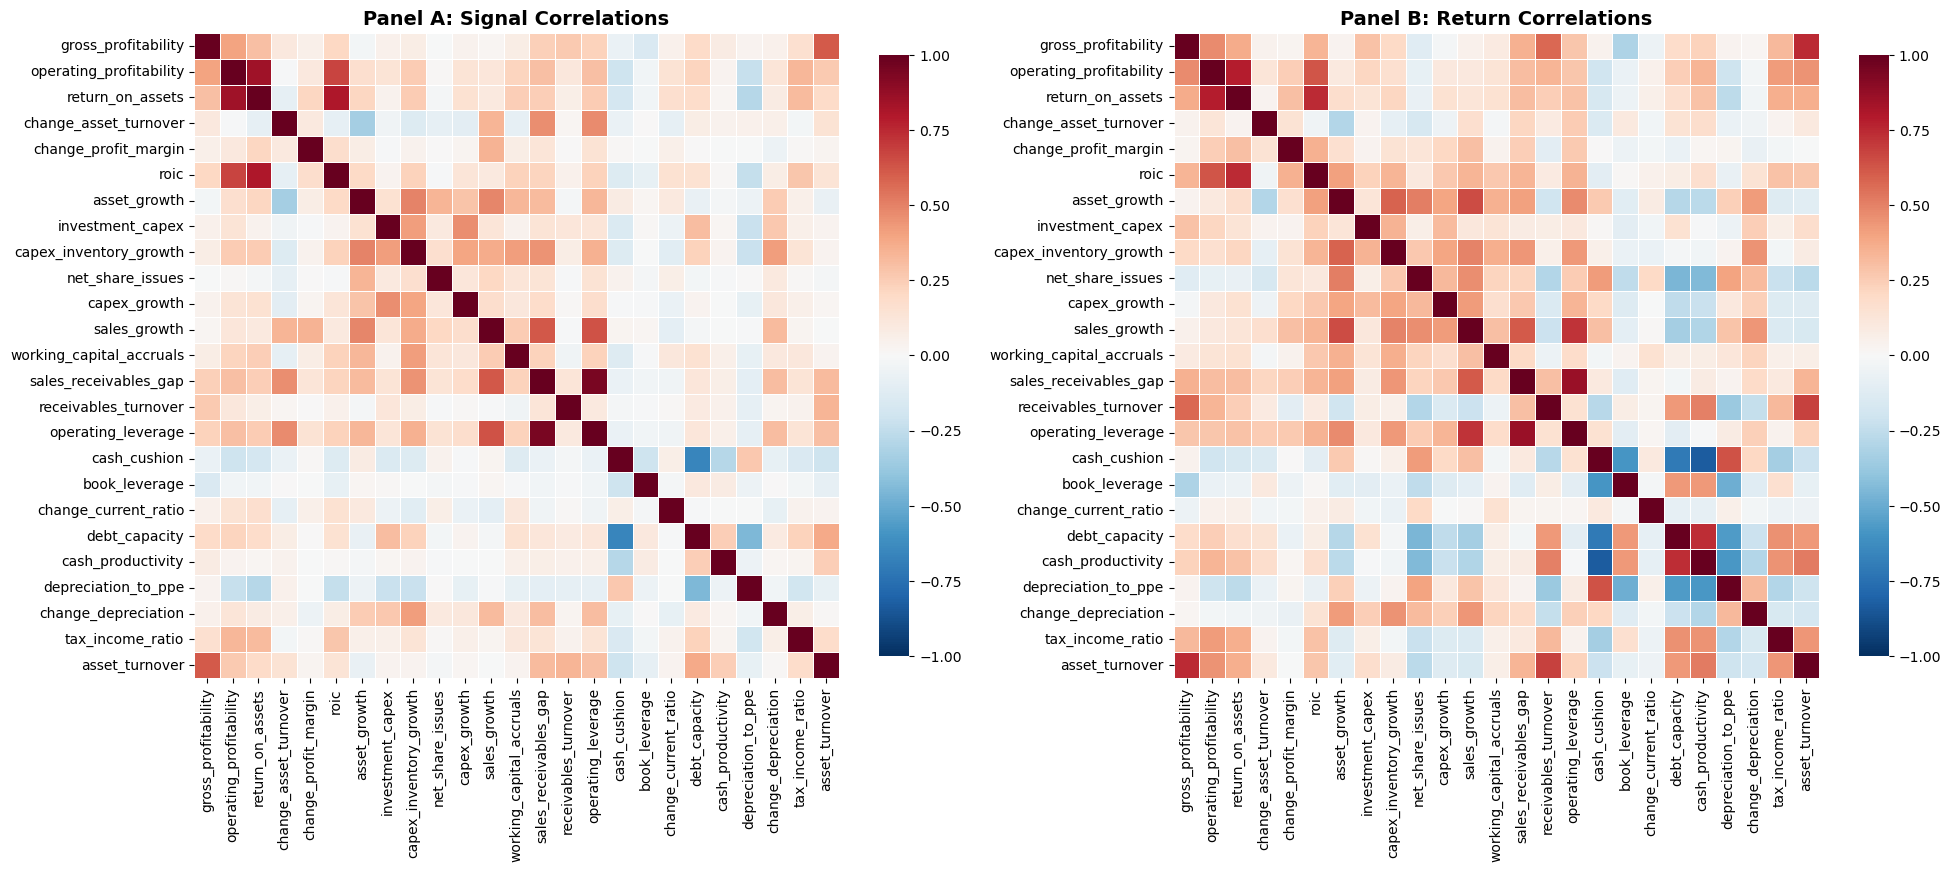

In [11]:
"""
════════════════════════════════════════════════════════════════════════════════
TABLE A5: CORRELATION ANALYSIS
════════════════════════════════════════════════════════════════════════════════
Panel A: Signal Correlations (Raw Values)
Panel B: Return Correlations (Long-Short Strategies)
"""

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

SIGNALS_FILE = Path('data/signals/signals_ALL.parquet')
PORTFOLIOS_DIR = Path('data/portfolios')

SIGNALS = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio', 'asset_turnover'
]

print("="*80)
print("TABLE A5: CORRELATION ANALYSIS")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════
# PANEL A: SIGNAL CORRELATIONS (Raw Values)
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 PANEL A: Signal Correlations (Raw Values)")
print("="*80)

# Charger signaux
df_signals = pd.read_parquet(SIGNALS_FILE)
# Filter to study period (July 1963 - June 2024)
df_signals.index = pd.to_datetime(df_signals.index)
df_signals = df_signals[(df_signals.index >= '1963-07-31') & (df_signals.index <= '2024-06-28')]


# Sélectionner colonnes des signaux
signal_data = df_signals[SIGNALS].copy()

# Calculer corrélation (pairwise, ignore NaN)
corr_signals = signal_data.corr(method='pearson')

print("\nCorrelation Matrix (25×25):")
print(f"  Mean correlation: {corr_signals.values[np.triu_indices_from(corr_signals.values, k=1)].mean():.3f}")
print(f"  Max correlation: {corr_signals.values[np.triu_indices_from(corr_signals.values, k=1)].max():.3f}")
print(f"  Min correlation: {corr_signals.values[np.triu_indices_from(corr_signals.values, k=1)].min():.3f}")

# Trouver les paires les plus corrélées
# Exclure la diagonale (corrélation avec soi-même)
corr_upper = corr_signals.where(np.triu(np.ones(corr_signals.shape), k=1).astype(bool))
corr_unstacked = corr_upper.unstack().dropna().sort_values(ascending=False)

# Filtrer les corrélations = 1.0 (identiques)
corr_unstacked = corr_unstacked[corr_unstacked < 0.9999]

print("\n🔝 Top 5 highest correlations:")
for i, (pair, corr) in enumerate(corr_unstacked.head(5).items(), 1):
    print(f"   {i}. {pair[0]} × {pair[1]}: {corr:.3f}")

print("\n🔽 Top 5 lowest correlations:")
for i, (pair, corr) in enumerate(corr_unstacked.tail(5).items(), 1):
    print(f"   {i}. {pair[0]} × {pair[1]}: {corr:.3f}")

# ════════════════════════════════════════════════════════════════════════════
# PANEL B: RETURN CORRELATIONS (Long-Short Strategies)
# ════════════════════════════════════════════════════════════════════════════

print("\n\n📊 PANEL B: Return Correlations (Long-Short)")
print("="*80)

# Charger returns de tous les portfolios
returns_dict = {}

for signal in SIGNALS:
    portfolio_file = PORTFOLIOS_DIR / f'{signal}_signal.parquet'
    
    if not portfolio_file.exists():
        print(f"⚠️  Missing: {signal}")
        continue
    
    df_port = pd.read_parquet(portfolio_file)
    
    # Utiliser returns Long-Short Equal-Weight
    returns_dict[signal] = df_port.set_index('date')['ret_ls_ew']

# Créer DataFrame de returns
df_returns = pd.DataFrame(returns_dict)

# Calculer corrélation
corr_returns = df_returns.corr(method='pearson')

print("\nReturn Correlation Matrix (25×25):")
print(f"  Mean correlation: {corr_returns.values[np.triu_indices_from(corr_returns.values, k=1)].mean():.3f}")
print(f"  Max correlation: {corr_returns.values[np.triu_indices_from(corr_returns.values, k=1)].max():.3f}")
print(f"  Min correlation: {corr_returns.values[np.triu_indices_from(corr_returns.values, k=1)].min():.3f}")

# Trouver les paires les plus corrélées (CORRIGÉ)
corr_upper_ret = corr_returns.where(np.triu(np.ones(corr_returns.shape), k=1).astype(bool))
corr_unstacked_ret = corr_upper_ret.unstack()

# ✅ CORRECTION: Filtrer NaN et corrélations parfaites (1.0)
corr_unstacked_ret = corr_unstacked_ret.dropna()
corr_unstacked_ret = corr_unstacked_ret[corr_unstacked_ret < 0.9999]  # Exclure identiques
corr_unstacked_ret = corr_unstacked_ret.sort_values(ascending=False)

print("\n🔝 Top 5 highest return correlations:")
for i, (pair, corr) in enumerate(corr_unstacked_ret.head(5).items(), 1):
    print(f"   {i}. {pair[0]} × {pair[1]}: {corr:.3f}")

print("\n🔽 Top 5 lowest return correlations:")
for i, (pair, corr) in enumerate(corr_unstacked_ret.tail(5).items(), 1):
    print(f"   {i}. {pair[0]} × {pair[1]}: {corr:.3f}")

# ════════════════════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)

# # Panel A
# corr_signals.to_csv('data/table_a5_panel_a_signal_correlations.csv')
# print("✅ Panel A saved to: data/table_a5_panel_a_signal_correlations.csv")

# # Panel B
# corr_returns.to_csv('data/table_a5_panel_b_return_correlations.csv')
# print("✅ Panel B saved to: data/table_a5_panel_b_return_correlations.csv")

# ════════════════════════════════════════════════════════════════════════════
# HEATMAP VISUALIZATION (Optional)
# ════════════════════════════════════════════════════════════════════════════

# Décommente si tu veux générer des heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel A
sns.heatmap(corr_signals, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=axes[0])
axes[0].set_title('Panel A: Signal Correlations', fontsize=14, fontweight='bold')

# Panel B
sns.heatmap(corr_returns, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=axes[1])
axes[1].set_title('Panel B: Return Correlations', fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('data/figure_a1_correlation_heatmaps.png', dpi=300, bbox_inches='tight')
# print("✅ Heatmap saved to: data/figure_a1_correlation_heatmaps.png")

print("="*80)


GENERATING CORRELATION HEATMAPS (SEPARATED)

📊 Loading signal data...

📊 Loading portfolio returns...
✓ Matrices loaded: (25, 25) & (25, 25)

FIGURE A3: SIGNAL CORRELATIONS

✅ FIGURE A3 SAVED: results/figures/appendix/s02_appendix_A3_signal_correlations.png


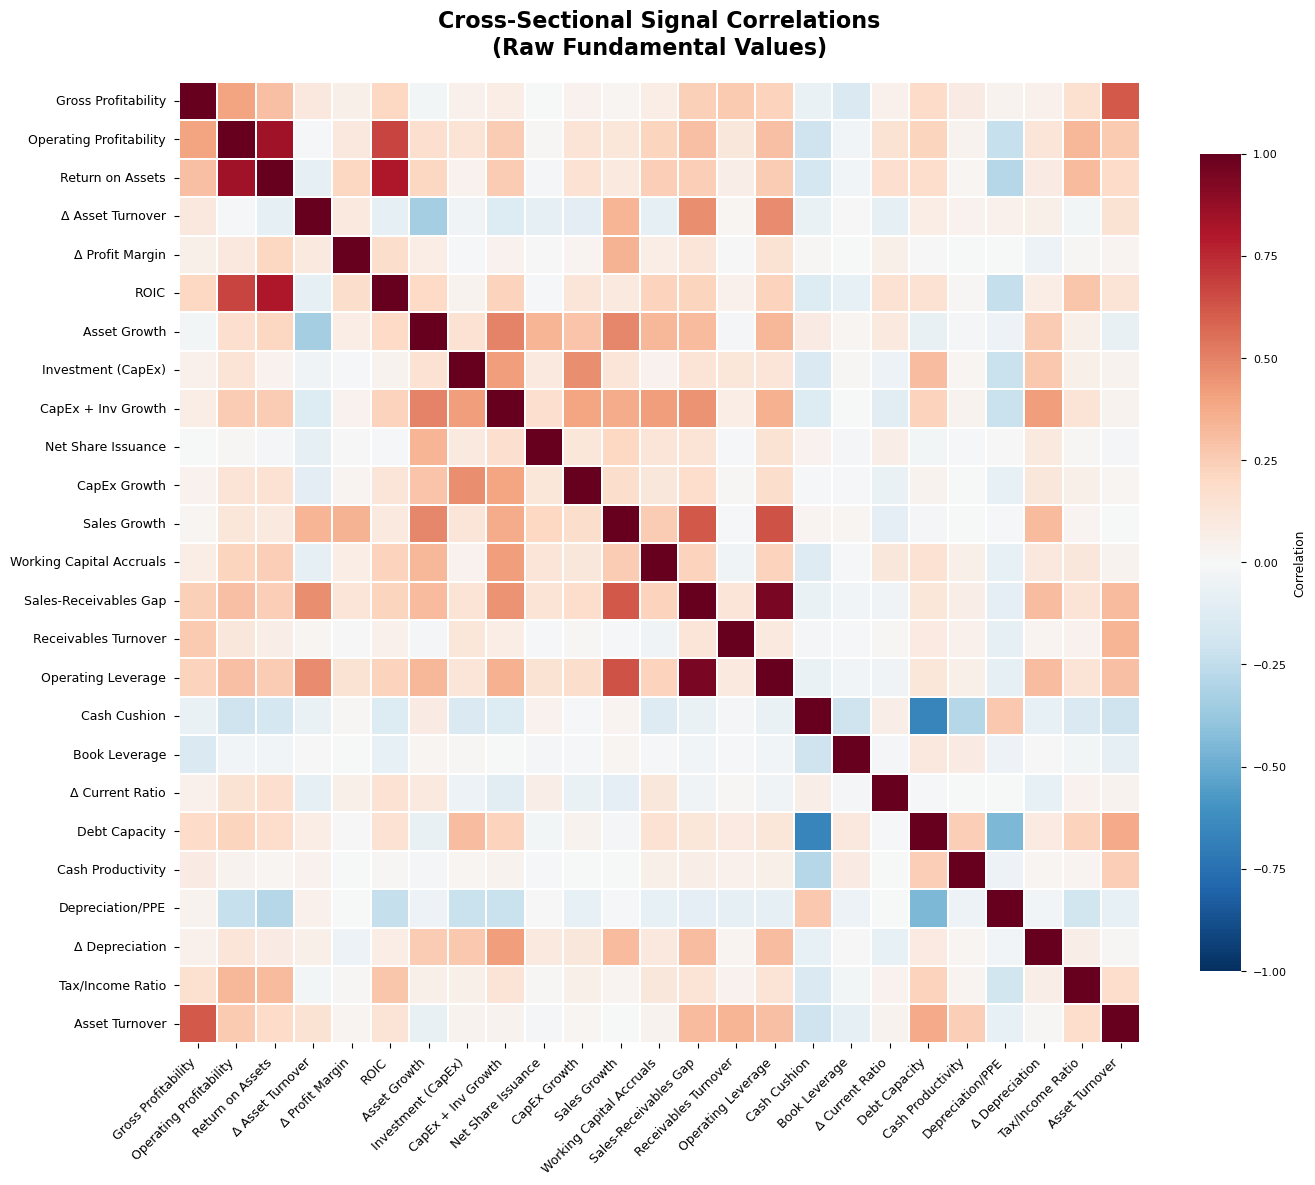


FIGURE A4: RETURN CORRELATIONS

✅ FIGURE A4 SAVED: results/figures/appendix/s02_appendix_A4_return_correlations.png


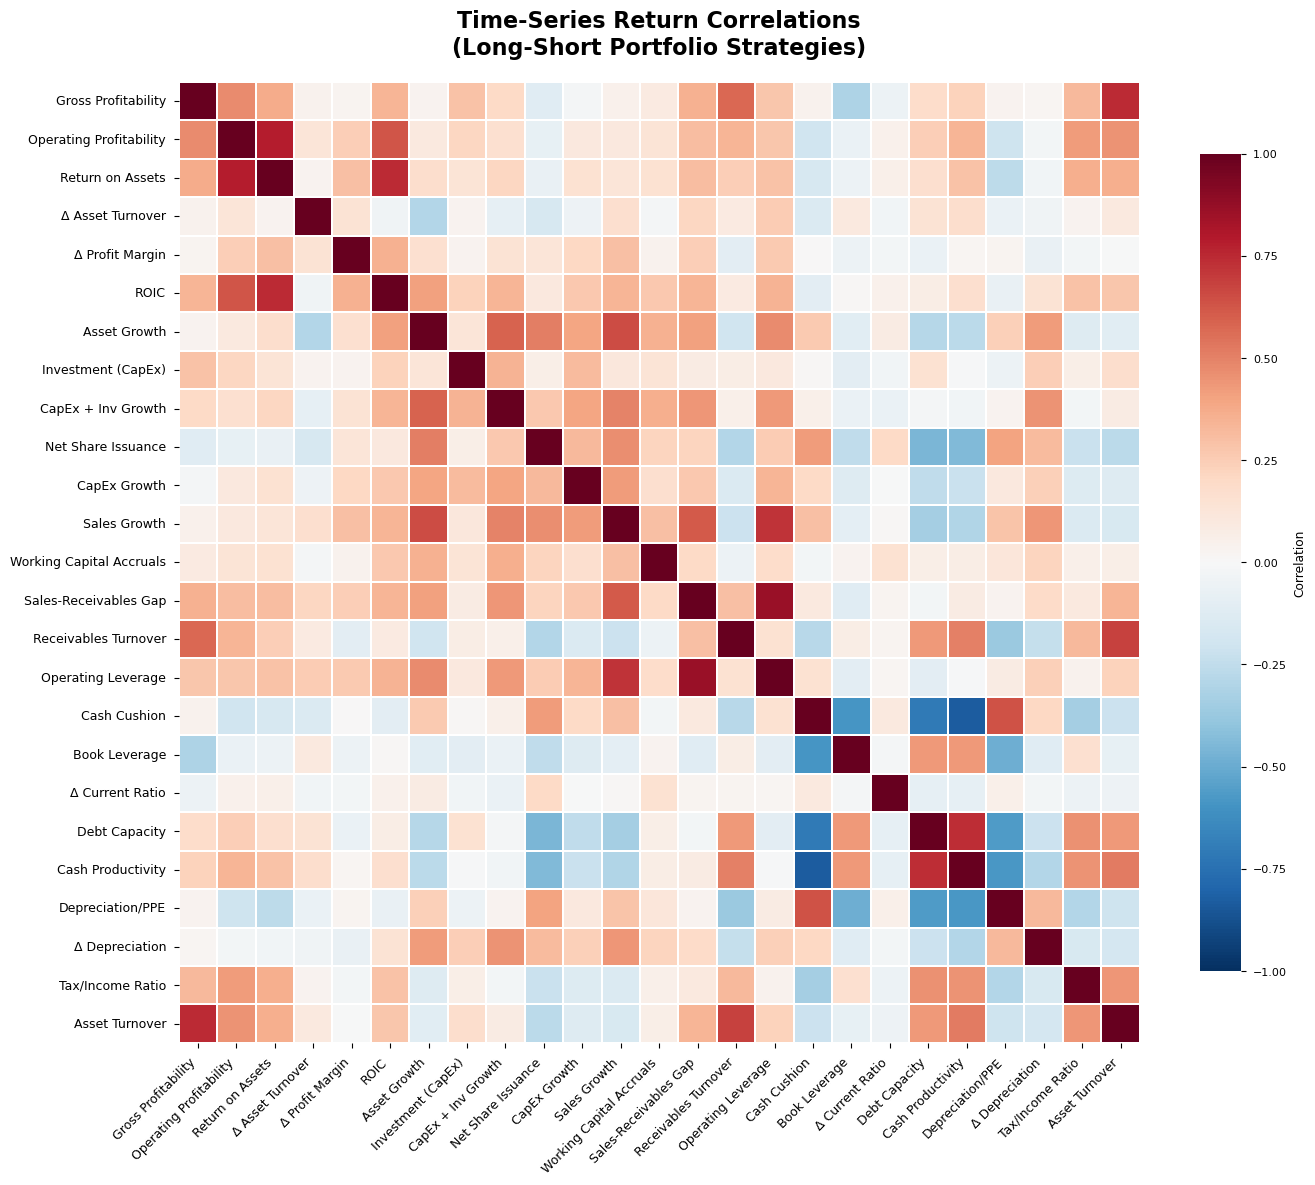

In [12]:
"""
════════════════════════════════════════════════════════════════════════════════
FIGURE A3 & A4: CORRELATION HEATMAPS (SEPARATED)
════════════════════════════════════════════════════════════════════════════════
Panel A: Signal Correlations (Raw Values)
Panel B: Return Correlations (Long-Short Strategies)
"""

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

SIGNALS_FILE = Path('data/signals/signals_ALL.parquet')
PORTFOLIOS_DIR = Path('data/portfolios')
OUTPUT_DIR = Path('results/figures/appendix')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIGNALS = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio', 'asset_turnover'
]

# ✅ NOMS COMPLETS (pour lisibilité)
SIGNAL_NAMES_FULL = {
    'gross_profitability': 'Gross Profitability',
    'operating_profitability': 'Operating Profitability',
    'return_on_assets': 'Return on Assets',
    'change_asset_turnover': 'Δ Asset Turnover',
    'change_profit_margin': 'Δ Profit Margin',
    'roic': 'ROIC',
    'asset_growth': 'Asset Growth',
    'investment_capex': 'Investment (CapEx)',
    'capex_inventory_growth': 'CapEx + Inv Growth',
    'net_share_issues': 'Net Share Issuance',
    'capex_growth': 'CapEx Growth',
    'sales_growth': 'Sales Growth',
    'working_capital_accruals': 'Working Capital Accruals',
    'sales_receivables_gap': 'Sales-Receivables Gap',
    'receivables_turnover': 'Receivables Turnover',
    'operating_leverage': 'Operating Leverage',
    'cash_cushion': 'Cash Cushion',
    'book_leverage': 'Book Leverage',
    'change_current_ratio': 'Δ Current Ratio',
    'debt_capacity': 'Debt Capacity',
    'cash_productivity': 'Cash Productivity',
    'depreciation_to_ppe': 'Depreciation/PPE',
    'change_depreciation': 'Δ Depreciation',
    'tax_income_ratio': 'Tax/Income Ratio',
    'asset_turnover': 'Asset Turnover'
}

print("="*80)
print("GENERATING CORRELATION HEATMAPS (SEPARATED)")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════
# LOAD DATA (Une seule fois)
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 Loading signal data...")
df_signals = pd.read_parquet(SIGNALS_FILE)
# Filter to study period (July 1963 - June 2024)
df_signals.index = pd.to_datetime(df_signals.index)
df_signals = df_signals[(df_signals.index >= '1963-07-31') & (df_signals.index <= '2024-06-28')]

signal_data = df_signals[SIGNALS].copy()
signal_data.columns = [SIGNAL_NAMES_FULL[col] for col in signal_data.columns]
corr_signals = signal_data.corr(method='pearson')

print("\n📊 Loading portfolio returns...")
returns_dict = {}
for signal in SIGNALS:
    portfolio_file = PORTFOLIOS_DIR / f'{signal}_signal.parquet'
    if portfolio_file.exists():
        df_port = pd.read_parquet(portfolio_file)
        returns_dict[SIGNAL_NAMES_FULL[signal]] = df_port.set_index('date')['ret_ls_ew']

df_returns = pd.DataFrame(returns_dict)
corr_returns = df_returns.corr(method='pearson')

print(f"✓ Matrices loaded: {corr_signals.shape} & {corr_returns.shape}\n")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE A3: SIGNAL CORRELATIONS
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("FIGURE A3: SIGNAL CORRELATIONS")
print("="*80)

plt.style.use('seaborn-v0_8-paper')
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_signals, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.3,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot=False,
    ax=ax
)

ax.set_title(
    'Cross-Sectional Signal Correlations\n(Raw Fundamental Values)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9, rotation=45)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_a3 = OUTPUT_DIR / 's02_appendix_A3_signal_correlations.png'
plt.savefig(output_a3, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ FIGURE A3 SAVED: {output_a3}")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE A4: RETURN CORRELATIONS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FIGURE A4: RETURN CORRELATIONS")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_returns, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.3,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot=False,
    ax=ax
)

ax.set_title(
    'Time-Series Return Correlations\n(Long-Short Portfolio Strategies)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9, rotation=45)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_a4 = OUTPUT_DIR / 's02_appendix_A4_return_correlations.png'
plt.savefig(output_a4, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ FIGURE A4 SAVED: {output_a4}")
print("="*80)
plt.show()

In [13]:
"""
════════════════════════════════════════════════════════════════════════════════
DISPLAY CORRELATION MATRICES (After Figure Generation)
════════════════════════════════════════════════════════════════════════════════
"""

import pandas as pd
import numpy as np

print("="*80)
print("CORRELATION MATRICES OVERVIEW")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════
# PANEL A: SIGNAL CORRELATIONS (Raw Values)
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 PANEL A: SIGNAL CORRELATIONS (RAW VALUES)")
print("="*80)
print(f"\nMatrix shape: {corr_signals.shape}")
print(f"Signals included: {len(corr_signals.columns)}\n")

# Display matrix avec formatage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 3)

print(corr_signals)

# Summary statistics
upper_triangle = corr_signals.values[np.triu_indices_from(corr_signals.values, k=1)]
print(f"\n📈 SUMMARY STATISTICS:")
print(f"   Mean correlation: {upper_triangle.mean():.3f}")
print(f"   Median correlation: {np.median(upper_triangle):.3f}")
print(f"   Std correlation: {upper_triangle.std():.3f}")
print(f"   Min correlation: {upper_triangle.min():.3f}")
print(f"   Max correlation: {upper_triangle.max():.3f}")

# Top correlations
corr_upper = corr_signals.where(np.triu(np.ones(corr_signals.shape), k=1).astype(bool))
corr_unstacked = corr_upper.unstack().dropna().sort_values(ascending=False)
corr_unstacked = corr_unstacked[corr_unstacked < 0.9999]

print("\n🔝 TOP 10 HIGHEST CORRELATIONS:")
for i, (pair, corr) in enumerate(corr_unstacked.head(10).items(), 1):
    print(f"   {i:2d}. {pair[0]:30s} × {pair[1]:30s}: {corr:6.3f}")

print("\n🔽 TOP 10 LOWEST CORRELATIONS:")
for i, (pair, corr) in enumerate(corr_unstacked.tail(10).items(), 1):
    print(f"   {i:2d}. {pair[0]:30s} × {pair[1]:30s}: {corr:6.3f}")

# ════════════════════════════════════════════════════════════════════════════
# PANEL B: RETURN CORRELATIONS (Long-Short)
# ════════════════════════════════════════════════════════════════════════════

print("\n\n📊 PANEL B: RETURN CORRELATIONS (LONG-SHORT)")
print("="*80)
print(f"\nMatrix shape: {corr_returns.shape}")
print(f"Portfolios included: {len(corr_returns.columns)}\n")

print(corr_returns)

# Summary statistics
upper_triangle_ret = corr_returns.values[np.triu_indices_from(corr_returns.values, k=1)]
print(f"\n📈 SUMMARY STATISTICS:")
print(f"   Mean correlation: {upper_triangle_ret.mean():.3f}")
print(f"   Median correlation: {np.median(upper_triangle_ret):.3f}")
print(f"   Std correlation: {upper_triangle_ret.std():.3f}")
print(f"   Min correlation: {upper_triangle_ret.min():.3f}")
print(f"   Max correlation: {upper_triangle_ret.max():.3f}")

# Top correlations
corr_upper_ret = corr_returns.where(np.triu(np.ones(corr_returns.shape), k=1).astype(bool))
corr_unstacked_ret = corr_upper_ret.unstack().dropna()
corr_unstacked_ret = corr_unstacked_ret[corr_unstacked_ret < 0.9999]
corr_unstacked_ret = corr_unstacked_ret.sort_values(ascending=False)

print("\n🔝 TOP 10 HIGHEST RETURN CORRELATIONS:")
for i, (pair, corr) in enumerate(corr_unstacked_ret.head(10).items(), 1):
    print(f"   {i:2d}. {pair[0]:30s} × {pair[1]:30s}: {corr:6.3f}")

print("\n🔽 TOP 10 LOWEST RETURN CORRELATIONS:")
for i, (pair, corr) in enumerate(corr_unstacked_ret.tail(10).items(), 1):
    print(f"   {i:2d}. {pair[0]:30s} × {pair[1]:30s}: {corr:6.3f}")

# ════════════════════════════════════════════════════════════════════════════
# COMPARISON
# ════════════════════════════════════════════════════════════════════════════

print("\n\n📊 COMPARISON: SIGNALS vs RETURNS")
print("="*80)
print(f"\n{'Metric':<30s} {'Signals':>12s} {'Returns':>12s} {'Difference':>12s}")
print("-"*80)
print(f"{'Mean Correlation':<30s} {upper_triangle.mean():12.3f} {upper_triangle_ret.mean():12.3f} {upper_triangle_ret.mean()-upper_triangle.mean():12.3f}")
print(f"{'Median Correlation':<30s} {np.median(upper_triangle):12.3f} {np.median(upper_triangle_ret):12.3f} {np.median(upper_triangle_ret)-np.median(upper_triangle):12.3f}")
print(f"{'Std Correlation':<30s} {upper_triangle.std():12.3f} {upper_triangle_ret.std():12.3f} {upper_triangle_ret.std()-upper_triangle.std():12.3f}")
print(f"{'Min Correlation':<30s} {upper_triangle.min():12.3f} {upper_triangle_ret.min():12.3f} {upper_triangle_ret.min()-upper_triangle.min():12.3f}")
print(f"{'Max Correlation':<30s} {upper_triangle.max():12.3f} {upper_triangle_ret.max():12.3f} {upper_triangle_ret.max()-upper_triangle.max():12.3f}")

print("\n" + "="*80)
print("✅ CORRELATION ANALYSIS COMPLETE")
print("="*80)

CORRELATION MATRICES OVERVIEW

📊 PANEL A: SIGNAL CORRELATIONS (RAW VALUES)

Matrix shape: (25, 25)
Signals included: 25

                          Gross Profitability  Operating Profitability  Return on Assets  Δ Asset Turnover  Δ Profit Margin   ROIC  Asset Growth  Investment (CapEx)  CapEx + Inv Growth  Net Share Issuance  CapEx Growth  Sales Growth  Working Capital Accruals  Sales-Receivables Gap  Receivables Turnover  Operating Leverage  Cash Cushion  Book Leverage  Δ Current Ratio  Debt Capacity  Cash Productivity  Depreciation/PPE  Δ Depreciation  Tax/Income Ratio  Asset Turnover
Gross Profitability                     1.000                    0.402             0.302             0.106        5.750e-02  0.210        -0.026               0.050               0.072              -0.004         0.041         0.021                     0.076                  0.238                 0.264               0.227        -0.070     -1.539e-01            0.051          0.194              0.085    